# Data Analysis

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sklearn.preprocessing as skp
from rich import print as rprint
import datetime
import dateutil
def get_creation_time(fpath: str):
    return os.path.getctime(fpath)

def timestamp2datetime(x: str)-> datetime.datetime:
    return datetime.datetime.fromtimestamp(x)

def dt2stringified_dt(dt) -> str:
    format = '%Y-%m-%d T %H:%M:%S'
    return dt.strftime(format)    

## Helpers

In [2]:
def extract_nr_of_sd_attributes(x: str) -> int:
    mi = re.match('.*-sd-(\d{3})-att', x)
    if mi is None or len(mi.groups()) < 1:
        raise Exception(f'Could not extract the number of selectively disclosed attributes from the given input string: {x}')
    return int(mi.group(1))

## Plotting variables

In [3]:
PALETTE="CMRmap"

## Data

In [4]:
fpath_records = './data/db-cs-concat-x.json' 

bname_records = os.path.basename(fpath_records).replace('.json','')
fpath_xl_output = os.path.join('data',f'{bname_records}.xlsx')
def get_df() -> pd.DataFrame:
    rprint(f'[bold red] Creating df from {fpath_records}')
    return pd.read_json(fpath_records)

In [5]:
df = get_df()
print('df.shape: ', df.shape)
print('df ∑nRecords: ', df.nRecords.sum())
print('df head')
display(df.head(3))
print('df tail')
display(df.tail(3))

# df.records: each value in this column is a list of records
# a: dataframe with exploded df.records, i.e., each row corresponds to a single record object
a = df.explode('records',)
print('a.shape: ', a.shape)
display(a.head(3))

# b: dataframe created from the records objects
b = a.records.apply(pd.Series)
print('b.shape: ', b.shape)
display(b.head(3))

 Creating df from ./data/db-cs-concat-x.json

df.shape:  (16659, 10)
df ∑nRecords:  116616
df head


,records,nRecords,cryptosuite,implementationClass,credentialSetupKey,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,end,start,iteration
0,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,mock-vc_002-sd-002-att,3,2,1739829605930,1739829605303,0
1,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",8,bbs-termwise-signature-2023,Implementation_BbsTermwiseSignature2023,mock-vc_002-sd-002-att,3,2,1739829606664,1739829605931,0
2,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",4,ed25519-signature-2020,Implementation_Ed25519Signature2020,mock-vc_002-sd-002-att,3,2,1739829606744,1739829606681,0


df tail


,records,nRecords,cryptosuite,implementationClass,credentialSetupKey,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,end,start,iteration
16656,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",8,bbs-termwise-signature-2023,Implementation_BbsTermwiseSignature2023,mock-vc_032-sd-032-att,33,32,1739831194771,1739831194051,99
16657,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",4,ed25519-signature-2020,Implementation_Ed25519Signature2020,mock-vc_032-sd-032-att,33,32,1739831194845,1739831194818,99
16658,"[{'name': 'START_SIGN_VC', 'entryType': 'mark'...",8,ecdsa-sd-2023-cryptosuite,Implementation_EcdsaSd2023Cryptosuite,mock-vc_032-sd-032-att,33,32,1739831194995,1739831194885,99


a.shape:  (116616, 10)


,records,nRecords,cryptosuite,implementationClass,credentialSetupKey,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,end,start,iteration
0,"{'name': 'START_SIGN_VC', 'entryType': 'mark',...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,mock-vc_002-sd-002-att,3,2,1739829605930,1739829605303,0
0,"{'name': 'END_SIGN_VC', 'entryType': 'mark', '...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,mock-vc_002-sd-002-att,3,2,1739829605930,1739829605303,0
0,"{'name': 'START_VERIFY_VC', 'entryType': 'mark...",8,bbs-bls-signature-2020,Implementation_BbsBlsSignature2020,mock-vc_002-sd-002-att,3,2,1739829605930,1739829605303,0


b.shape:  (116616, 5)


,name,entryType,startTime,duration,detail
0,START_SIGN_VC,mark,1077.833875,0,{'implementation': 'bbs-bls-signature-2020'}
0,END_SIGN_VC,mark,1330.729208,0,{'implementation': 'bbs-bls-signature-2020'}
0,START_VERIFY_VC,mark,1330.751542,0,{'implementation': 'bbs-bls-signature-2020'}


`c = merge(a,b)`

In [6]:
c = a[['iteration','implementationClass', 'credentialSetupKey', 'nrCredentialSubjectAttributes', 'nrDisclosedCredentialSubjectAttributes']]\
    .drop_duplicates()\
    .merge(b[['name', 'entryType', 'startTime']], left_index=True, right_index=True)
print('c.shape: ', c.shape)
display(c.head(3))

c.shape:  (116616, 8)


,iteration,implementationClass,credentialSetupKey,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,name,entryType,startTime
0,0,Implementation_BbsBlsSignature2020,mock-vc_002-sd-002-att,3,2,START_SIGN_VC,mark,1077.833875
0,0,Implementation_BbsBlsSignature2020,mock-vc_002-sd-002-att,3,2,END_SIGN_VC,mark,1330.729208
0,0,Implementation_BbsBlsSignature2020,mock-vc_002-sd-002-att,3,2,START_VERIFY_VC,mark,1330.751542


Filter: only keep `mark` entries.

In [7]:
d = c[c.entryType == 'mark']
print('d.shape: ', d.shape)
d.head(3)

d.shape:  (116616, 8)


,iteration,implementationClass,credentialSetupKey,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,name,entryType,startTime
0,0,Implementation_BbsBlsSignature2020,mock-vc_002-sd-002-att,3,2,START_SIGN_VC,mark,1077.833875
0,0,Implementation_BbsBlsSignature2020,mock-vc_002-sd-002-att,3,2,END_SIGN_VC,mark,1330.729208
0,0,Implementation_BbsBlsSignature2020,mock-vc_002-sd-002-att,3,2,START_VERIFY_VC,mark,1330.751542


Some final preprocessing.

In [8]:
e = d.drop('entryType', axis = 1) # We can drop the entryType as we already know all values are 'mark'.
# Extract implementation column.
e['implementation'] = e.implementationClass.str.split('_').apply(lambda x: x[-1])
e.drop('implementationClass', axis=1, inplace=True) # We no longer need this column.
# Extract step and step type from name as columns.
e['step'] = e['name'].apply(lambda x: '_'.join(x.split('_')[1:]))
e['stepType'] = e['name'].apply(lambda x: x.split('_')[0])
e.drop('name', axis=1, inplace=True) # We no longer need this column.
print('e.shape: ', e.shape)
display(e.head(3))

e.shape:  (116616, 8)


,iteration,credentialSetupKey,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,startTime,implementation,step,stepType
0,0,mock-vc_002-sd-002-att,3,2,1077.833875,BbsBlsSignature2020,SIGN_VC,START
0,0,mock-vc_002-sd-002-att,3,2,1330.729208,BbsBlsSignature2020,SIGN_VC,END
0,0,mock-vc_002-sd-002-att,3,2,1330.751542,BbsBlsSignature2020,VERIFY_VC,START


In [9]:
FALLBACK_TO_EXPERIMENTS_WITH_MAX_NR_OF_ITERATIONS = True
def get_dfa() -> pd.DataFrame:
    """ Get the analysis dataframe """
    # Create a copy of the last dataframe result from the previous section
    dfa = e.copy()

    dfa.set_index(['implementation', 'credentialSetupKey', 'iteration','step','stepType'], inplace=True)
    
    # Make sure that every experiment has the same nr of records
    s_nr_experiments = dfa\
        .reset_index().groupby(['credentialSetupKey', 'implementation', 'step','stepType', 'iteration'],as_index=False ).first()\
        .groupby(['credentialSetupKey', 'implementation', 'step', 'stepType']).size()
    
    if not FALLBACK_TO_EXPERIMENTS_WITH_MAX_NR_OF_ITERATIONS:
        assert s_nr_experiments.unique().__len__() == 1
        pass
    else:
        print('⚠️ Falling back to experiments with the max nr. of iterations!')
        vc_csk = dfa.reset_index().credentialSetupKey.value_counts()
        idx_csk_max_rows = vc_csk[vc_csk == vc_csk.max()].index
        dfa = dfa.loc(axis=0)[:, idx_csk_max_rows]
    
    return dfa

In [10]:
def get_df_meta() -> pd.DataFrame:
    df_meta = get_dfa().groupby(['credentialSetupKey'])['nrCredentialSubjectAttributes','nrDisclosedCredentialSubjectAttributes'].first().reset_index()
    df_meta['nrHiddenCredentialSubjectAttributes'] = df_meta['nrCredentialSubjectAttributes'] - df_meta['nrDisclosedCredentialSubjectAttributes']
    return df_meta

Node Performance Docs: <https://nodejs.org/api/perf_hooks.htm>

- `performanceEntry.startTime`: The high resolution millisecond timestamp marking the starting time of the Performance Entry.



In [11]:
dfa = get_dfa()
#dfa.set_index(['implementation', 'credentialSetupKey', 'iteration','step','stepType'], inplace=True)
print('dfa.shape: ', dfa.shape)
display(dfa.head(3))

⚠️ Falling back to experiments with the max nr. of iterations!
dfa.shape:  (109200, 3)


nrCredentialSubjectAttributes  \
implementation      credentialSetupKey     iteration step      stepType                                  
BbsBlsSignature2020 mock-vc_002-sd-002-att 0         SIGN_VC   START                                 3   
                                                               END                                   3   
                                                     VERIFY_VC START                                 3   

                                                                         nrDisclosedCredentialSubjectAttributes  \
implementation      credentialSetupKey     iteration step      stepType                                           
BbsBlsSignature2020 mock-vc_002-sd-002-att 0         SIGN_VC   START                                          2   
                                                               END                                            2   
                                                     VERIFY_VC START                                          2   

                                                                           startTime  
implementation      credentialSetupKey     iteration step      stepType               
BbsBlsSignature2020 mock-vc_002-sd-002-att 0         SIGN_VC   START     1077.833875  
                                                               END       1330.729208  
                                                     VERIFY_VC START     1330.751542

Compute delta execution time for each step

In [12]:
# Compute the duration delta between each step's start and end time
df_delta = dfa.startTime\
    .unstack('stepType')\
    .apply(lambda r: r.END - r.START, axis=1)\
    .to_frame('delta')

# merge with credential meta
df_delta.reset_index().merge(get_df_meta(), left_on='credentialSetupKey', right_on='credentialSetupKey').set_index(list(df_delta.index.names))

print('df_delta.shape: ', df_delta.shape)
display(df_delta.head(3))

⚠️ Falling back to experiments with the max nr. of iterations!
df_delta.shape:  (54600, 1)


/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_57094/2409186093.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  df_meta = get_dfa().groupby(['credentialSetupKey'])['nrCredentialSubjectAttributes','nrDisclosedCredentialSubjectAttributes'].first().reset_index()


delta
implementation      credentialSetupKey     iteration step                      
BbsBlsSignature2020 mock-vc_002-sd-002-att 0         DERIVE          235.628375
                                                     SIGN_VC         252.895333
                                                     VERIFY_DERIVED   44.470959

## Analysis

### Compute descriptive statistics

`df_stat`: the DataFrame containing descriptive statistics from `df_delta`.

In [13]:
df_stat = df_delta.copy()
df_stat.reset_index(inplace=True)
agg_funcs = ['mean','std', 'var','min','max','count']
df_stat = df_stat.groupby(['implementation', 'credentialSetupKey', 'step'])['delta'].agg(agg_funcs)
df_stat

mean  \
implementation       credentialSetupKey     step                         
BbsBlsSignature2020  mock-vc_002-sd-002-att DERIVE          182.249224   
                                            SIGN_VC          88.508661   
                                            VERIFY_DERIVED   53.147805   
                                            VERIFY_VC        47.199423   
                     mock-vc_004-sd-002-att DERIVE          251.800419   
...                                                                ...   
Ed25519Signature2020 mock-vc_512-sd-016-att VERIFY_VC        18.437190   
                     mock-vc_512-sd-032-att SIGN_VC          18.016523   
                                            VERIFY_VC        15.971673   
                     mock-vc_512-sd-064-att SIGN_VC          16.259399   
                                            VERIFY_VC        17.577580   

                                                                   std  \
implementation       credentialSetupKey     step                         
BbsBlsSignature2020  mock-vc_002-sd-002-att DERIVE           35.055821   
                                            SIGN_VC          25.672265   
                                            VERIFY_DERIVED   46.609744   
                                            VERIFY_VC         8.970310   
                     mock-vc_004-sd-002-att DERIVE          106.957153   
...                                                                ...   
Ed25519Signature2020 mock-vc_512-sd-016-att VERIFY_VC         6.382142   
                     mock-vc_512-sd-032-att SIGN_VC           3.345680   
                                            VERIFY_VC         2.234333   
                     mock-vc_512-sd-064-att SIGN_VC           1.651888   
                                            VERIFY_VC         2.181520   

                                                                     var  \
implementation       credentialSetupKey     step                           
BbsBlsSignature2020  mock-vc_002-sd-002-att DERIVE           1228.910563   
                                            SIGN_VC           659.065189   
                                            VERIFY_DERIVED   2172.468194   
                                            VERIFY_VC          80.466470   
                     mock-vc_004-sd-002-att DERIVE          11439.832499   
...                                                                  ...   
Ed25519Signature2020 mock-vc_512-sd-016-att VERIFY_VC          40.731742   
                     mock-vc_512-sd-032-att SIGN_VC            11.193573   
                                            VERIFY_VC           4.992242   
                     mock-vc_512-sd-064-att SIGN_VC             2.728735   
                                            VERIFY_VC           4.759031   

                                                                   min  \
implementation       credentialSetupKey     step                         
BbsBlsSignature2020  mock-vc_002-sd-002-att DERIVE          144.642375   
                                            SIGN_VC          66.823584   
                                            VERIFY_DERIVED   40.547500   
                                            VERIFY_VC        40.229750   
                     mock-vc_004-sd-002-att DERIVE          150.552584   
...                                                                ...   
Ed25519Signature2020 mock-vc_512-sd-016-att VERIFY_VC        14.112041   
                     mock-vc_512-sd-032-att SIGN_VC          15.111625   
                                            VERIFY_VC        14.252291   
                     mock-vc_512-sd-064-att SIGN_VC          14.825167   
                                            VERIFY_VC        14.504000   

                                                                   max  count  
implementation       credentialSetupKey     step                               
BbsBlsSignature2020  mock-vc

### Mean execution times

`df_mean`: DataFrame focussing on the mean execution time per step, for each crypto suite implementation.

In [14]:
step_order = ['SIGN_VC', 'VERIFY_VC', 'DERIVE', 'VERIFY_DERIVED']
df_mean = df_stat['mean']\
    .unstack(['implementation','credentialSetupKey'])\
    .reorder_levels(['implementation','credentialSetupKey',],axis=1)\
    .loc[step_order]\
    .round(2)
df_mean

implementation        BbsBlsSignature2020                         \
credentialSetupKey mock-vc_002-sd-002-att mock-vc_004-sd-002-att   
step                                                               
SIGN_VC                             88.51                  88.37   
VERIFY_VC                           47.20                  49.59   
DERIVE                             182.25                 251.80   
VERIFY_DERIVED                      53.15                  51.28   

implementation                                                    \
credentialSetupKey mock-vc_004-sd-004-att mock-vc_008-sd-002-att   
step                                                               
SIGN_VC                             95.33                 103.72   
VERIFY_VC                           58.76                  61.81   
DERIVE                             394.34                 406.19   
VERIFY_DERIVED                      56.41                  63.54   

implementation                                                    \
credentialSetupKey mock-vc_008-sd-004-att mock-vc_008-sd-008-att   
step                                                               
SIGN_VC                             98.62                  95.86   
VERIFY_VC                           63.77                  64.24   
DERIVE                             411.76                 405.51   
VERIFY_DERIVED                      61.76                  59.12   

implementation                                                    \
credentialSetupKey mock-vc_016-sd-002-att mock-vc_016-sd-004-att   
step                                                               
SIGN_VC                             96.22                 103.31   
VERIFY_VC                           64.12                  67.56   
DERIVE                             210.58                 292.06   
VERIFY_DERIVED                      62.76                  62.18   

implementation                                                    ...  \
credentialSetupKey mock-vc_016-sd-008-att mock-vc_016-sd-016-att  ...   
step                                                              ...   
SIGN_VC                            102.86                 109.38  ...   
VERIFY_VC                           78.01                  70.34  ...   
DERIVE                             418.27                 418.36  ...   
VERIFY_DERIVED                      69.45                  68.95  ...   

implementation       Ed25519Signature2020                         \
credentialSetupKey mock-vc_256-sd-032-att mock-vc_256-sd-064-att   
step                                                               
SIGN_VC                             16.33                  17.24   
VERIFY_VC                           17.94                  16.11   
DERIVE                                NaN                    NaN   
VERIFY_DERIVED                        NaN                    NaN   

implementation                                                    \
credentialSetupKey mock-vc_256-sd-128-att mock-vc_256-sd-256-att   
step                                                               
SIGN_VC                             15.97                  15.97   
VERIFY_VC                           17.15                  17.05   
DERIVE                                NaN                    NaN   
VERIFY_DERIVED                        NaN                    NaN   

implementation                                                    \
credentialSetupKey mock-vc_512-sd-002-att mock-vc_512-sd-004-att   
step                                                               
SIGN_VC                             24.54                  17.67   
VERIFY_VC                           28.93                  17.51   
DERIVE                                NaN                    NaN   
VERIFY_DERIVED                        NaN                    NaN   

implementation                                                    \
credentialSetupKey mock-vc_512-sd-008-att mock-vc_512-sd-016-att   
step         

In [15]:
df_stat.to_excel(fpath_xl_output, 'mean_execution_times')

---

## Results (transformed and scaled)

### `dfa`

In [16]:
# Make sure that the sample sizes for each credential setup are the same
assert dfa.reset_index().credentialSetupKey.value_counts(dropna=False).value_counts().shape[0] == 1

In [17]:
dfa_w = dfa.unstack(['implementation', 'credentialSetupKey', 'stepType'])
display(dfa_w.head(3))
dfa_w.shape

nrCredentialSubjectAttributes       \
implementation                     BbsBlsSignature2020        
credentialSetupKey              mock-vc_002-sd-002-att        
stepType                                         START  END   
iteration step                                                
0         DERIVE                                   3.0  3.0   
          SIGN_VC                                  3.0  3.0   
          VERIFY_DERIVED                           3.0  3.0   

                                                                               \
implementation           BbsTermwiseSignature2023        Ed25519Signature2020   
credentialSetupKey         mock-vc_002-sd-002-att      mock-vc_002-sd-002-att   
stepType                                    START  END                  START   
iteration step                                                                  
0         DERIVE                              3.0  3.0                    NaN   
          SIGN_VC                             3.0  3.0                    3.0   
          VERIFY_DERIVED                      3.0  3.0                    NaN   

                                                           \
implementation                EcdsaSd2023Cryptosuite        
credentialSetupKey            mock-vc_002-sd-002-att        
stepType                  END                  START  END   
iteration step                                              
0         DERIVE          NaN                    3.0  3.0   
          SIGN_VC         3.0                    3.0  3.0   
          VERIFY_DERIVED  NaN                    3.0  3.0   

                                                          ...  \
implementation               BbsBlsSignature2020          ...   
credentialSetupKey       mock-vc_2048-sd-002-att          ...   
stepType                                   START     END  ...   
iteration step                                            ...   
0         DERIVE                          2049.0  2049.0  ...   
          SIGN_VC                         2049.0  2049.0  ...   
          VERIFY_DERIVED                  2049.0  2049.0  ...   

                                      startTime                \
implementation           EcdsaSd2023Cryptosuite                 
credentialSetupKey       mock-vc_256-sd-064-att                 
stepType                                  START           END   
iteration step                                                  
0         DERIVE                   2.794344e+06  2.794392e+06   
          SIGN_VC                  2.794281e+06  2.794325e+06   
          VERIFY_DERIVED           2.794392e+06  2.794407e+06   

                                                               \
implementation              BbsBlsSignature2020                 
credentialSetupKey       mock-vc_032-sd-032-att                 
stepType                                  START           END   
iteration step                                                  
0         DERIVE                   1.406034e+06  1.406386e+06   
          SIGN_VC                  1.405856e+06  1.405957e+06   
          VERIFY_DERIVED           1.406386e+06  1.406451e+06   

                                                                 \
implementation           BbsTermwiseSignature2023                 
credentialSetupKey         mock-vc_032-sd-032-att                 
stepType                                    START           END   
iteration step                                                    
0         DERIVE                     1.406859e+06  1.407152e+06   
          SIGN_VC                    1.406556e+06  1.406679e+06   
          VERIFY_DERIVED             1.407152e+06  1.407296e+06   

                                                               \
implementation             Ed25519Signature2020                 
credentialSetupKey       mock-vc_032-sd-032-att                 
stepType                                  START           END   
iteration step        

(400, 936)

In [18]:
# dfa_w01: Only SIGN and VERIFY steps
dfa_w01 = dfa_w.drop(['DERIVE', 'VERIFY_DERIVED'], level=1)
# dfa_w02: Only DERIVE and VERIFY_DERIVED steps
dfa_w02 = dfa_w.drop(['SIGN_VC', 'VERIFY_VC'], level=1)

In [19]:
dfa_w01

nrCredentialSubjectAttributes       \
implementation                BbsBlsSignature2020        
credentialSetupKey         mock-vc_002-sd-002-att        
stepType                                    START  END   
iteration step                                           
0         SIGN_VC                             3.0  3.0   
          VERIFY_VC                           3.0  3.0   
1         SIGN_VC                             3.0  3.0   
          VERIFY_VC                           3.0  3.0   
2         SIGN_VC                             3.0  3.0   
...                                           ...  ...   
97        VERIFY_VC                           3.0  3.0   
98        SIGN_VC                             3.0  3.0   
          VERIFY_VC                           3.0  3.0   
99        SIGN_VC                             3.0  3.0   
          VERIFY_VC                           3.0  3.0   

                                                                               \
implementation      BbsTermwiseSignature2023        Ed25519Signature2020        
credentialSetupKey    mock-vc_002-sd-002-att      mock-vc_002-sd-002-att        
stepType                               START  END                  START  END   
iteration step                                                                  
0         SIGN_VC                        3.0  3.0                    3.0  3.0   
          VERIFY_VC                      3.0  3.0                    3.0  3.0   
1         SIGN_VC                        3.0  3.0                    3.0  3.0   
          VERIFY_VC                      3.0  3.0                    3.0  3.0   
2         SIGN_VC                        3.0  3.0                    3.0  3.0   
...                                      ...  ...                    ...  ...   
97        VERIFY_VC                      3.0  3.0                    3.0  3.0   
98        SIGN_VC                        3.0  3.0                    3.0  3.0   
          VERIFY_VC                      3.0  3.0                    3.0  3.0   
99        SIGN_VC                        3.0  3.0                    3.0  3.0   
          VERIFY_VC                      3.0  3.0                    3.0  3.0   

                                                                         \
implementation      EcdsaSd2023Cryptosuite          BbsBlsSignature2020   
credentialSetupKey  mock-vc_002-sd-002-att      mock-vc_2048-sd-002-att   
stepType                             START  END                   START   
iteration step                                                            
0         SIGN_VC                      3.0  3.0                  2049.0   
          VERIFY_VC                    3.0  3.0                  2049.0   
1         SIGN_VC                      3.0  3.0                  2049.0   
          VERIFY_VC                    3.0  3.0                  2049.0   
2         SIGN_VC                      3.0  3.0                  2049.0   
...                                    ...  ...                     ...   
97        VERIFY_VC                    3.0  3.0                  2049.0   
98        SIGN_VC                      3.0  3.0                  2049.0   
          VERIFY_VC                    3.0  3.0                  2049.0   
99        SIGN_VC                      3.0  3.0                  2049.0   
          VERIFY_VC                    3.0  3.0                  2049.0   

                             ...              startTime                \
implementation               ... EcdsaSd2023Cryptosuite                 
credentialSetupKey           ... mock-vc_256-sd-064-att                 
stepType                END  ...                  START           END   
iteration step               ...                                        
0         SIGN_VC    2049.0  ...           2.794281e+06  2.794325e+06   
          VERIFY_VC  2049.0  ...           2.794325e+06  2.794344e+06   
1         SIGN_VC    2049.0  ...           2.799442e+06  2.799485e+06   
         

In [20]:
def scale(df: pd.DataFrame) -> pd.DataFrame:
    sclr = skp.StandardScaler()
    return pd.DataFrame(
        data = sclr.fit_transform(df),
        columns = df.columns,
        index = df.index
    )
def add_delta_col(df: pd.DataFrame) -> pd.DataFrame:
    tmp = df.stack([0,1,2])
    tmp = (tmp.END - tmp.START).droplevel(level=2).rename('delta')
    return tmp.reset_index()

def add_credential_col(df: pd.DataFrame) -> pd.DataFrame:
    df['credential'] = pd.Series(df.credentialSetupKey.str.split('-sd-').apply(lambda x: x[0]).values)
    return df

def add_n_sd_att_col(df: pd.DataFrame) -> pd.DataFrame:
    df['n_sd_att'] = df.credentialSetupKey.apply(extract_nr_of_sd_attributes)
    return df

def run_preprocessing_steps(df: pd.DataFrame) -> pd.DataFrame:
    df_scld = scale(df)
    df_scld = add_delta_col(df_scld)
    df_scld = add_credential_col(df_scld)
    df_scld = add_n_sd_att_col(df_scld)
    return df_scld

In [21]:
dfsb_dfa_w01 = run_preprocessing_steps(dfa_w01)
dfsb_dfa_w02 = run_preprocessing_steps(dfa_w02)

/Users/gertjandm/miniforge3/lib/python3.9/site-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/Users/gertjandm/miniforge3/lib/python3.9/site-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/Users/gertjandm/miniforge3/lib/python3.9/site-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


SIGN AND VERIFY

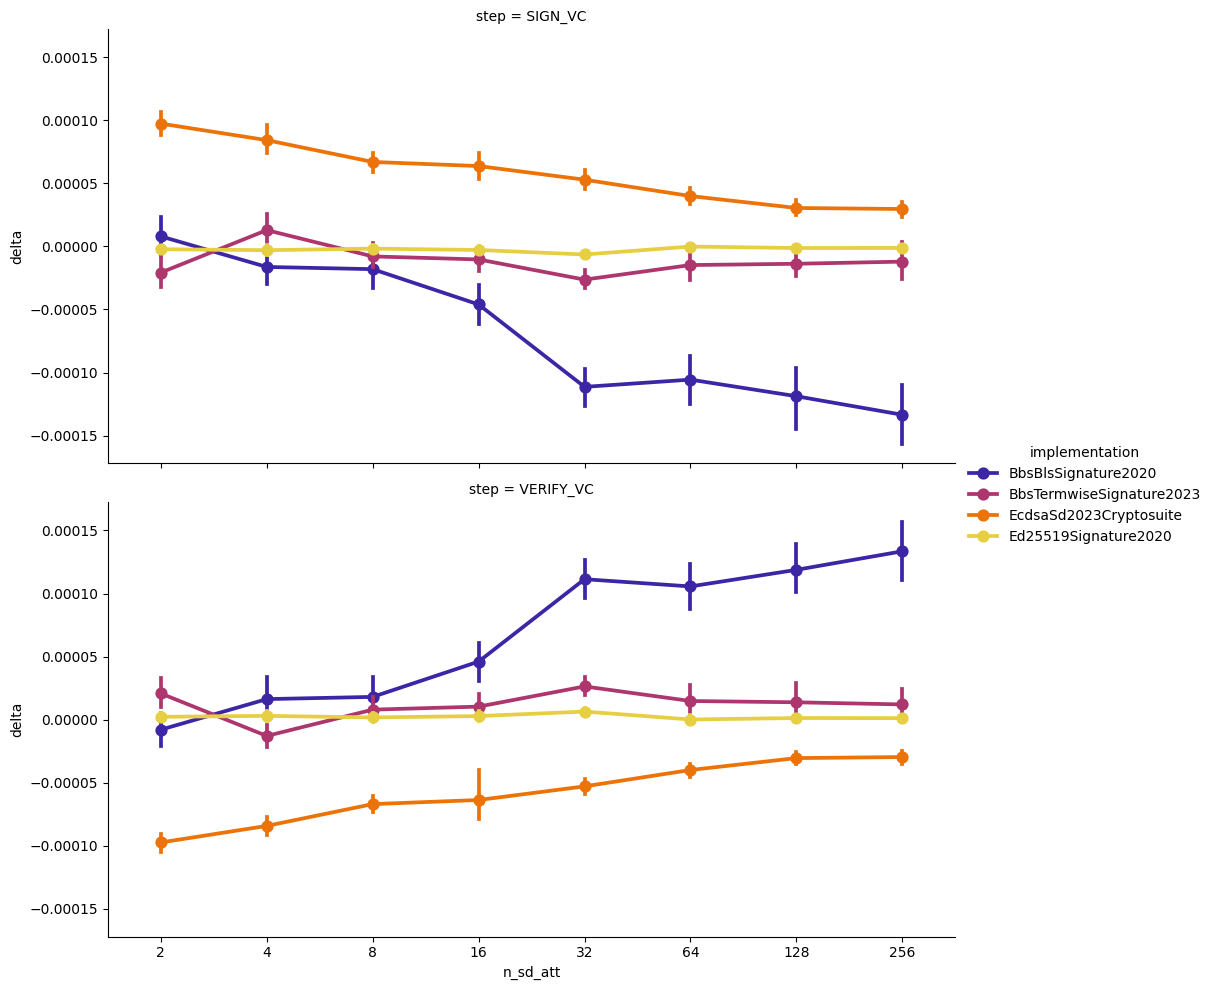

In [22]:
# SIGN AND VERIFY
snsdata = dfsb_dfa_w01.copy()
g = sns.catplot(
        data = snsdata,
        x = 'n_sd_att',
        y = 'delta',
        hue = 'implementation',
        row = 'step',
        row_order = ['SIGN_VC', 'VERIFY_VC'],
        kind = 'point',
        aspect=2,
        sharey=True,
        palette=PALETTE
    )

DERIVE & VERIFY_DERIVED

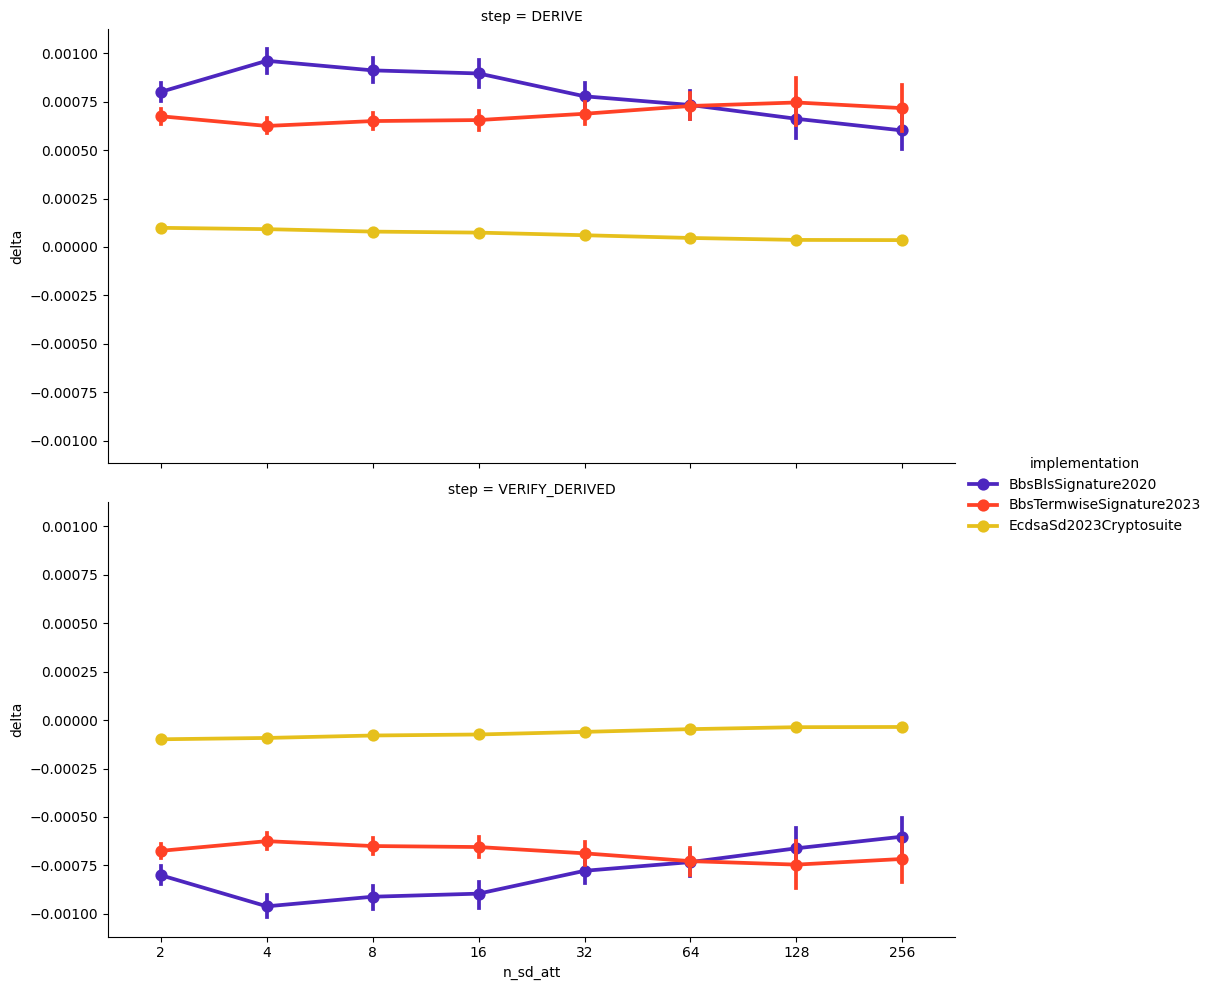

In [23]:
# DERIVE & VERIFY_DERIVED

snsdata = dfsb_dfa_w02.copy()

g = sns.catplot(
        data = snsdata,
        x = 'n_sd_att',
        y = 'delta',
        row = 'step',
        row_order = ['DERIVE', 'VERIFY_DERIVED'],
        hue = 'implementation',
        kind = 'point',
        aspect=2,
        sharey=True, 
        palette=PALETTE
    )

### `dfb`

In [24]:
dfb = df_delta.unstack(['step','credentialSetupKey']).delta

### VC operation subsets

We consider the following VC operation subsets:
- ['SIGN_VC', 'VERIFY_VC']: these columns strictly contain numeric values for every implementation.
- ['DERIVE', 'VERIFY_DERIVED']: these columns only contain numeric values for implementations that support selective disclosure. An implementation that does not support selective disclosure would have NaN values for these columns. You cannot feed NaN values into a scaler without imputing them. However, there's no reason to impute these values. Hence, the separation.

In [25]:
b_01_cols = ['SIGN_VC', 'VERIFY_VC']
b_02_cols = ['DERIVE', 'VERIFY_DERIVED']
col_order = b_01_cols + b_02_cols

In [26]:
# Create subsets
dfb_01 = dfb[b_01_cols]
dfb_02 = dfb[b_02_cols]

# Log-transform
dfb_01 = dfb_01.apply(np.log)
dfb_02 = dfb_02.apply(np.log)

dfb_01.shape, dfb_02.shape

((400, 78), (400, 78))

Scale subsets

In [27]:
dfb_01_scld = scale(dfb_01)
dfb_02_scld = scale(dfb_02)

Preprocess the subset dataframes into a form and shape that seaborn wants.

In [28]:
snsdata_b01 = dfb_01_scld.stack([0,1]).rename('delta_scld').reset_index()
snsdata_b02 = dfb_02_scld.stack([0,1]).rename('delta_scld').reset_index()
# preprocessing
snsdata_b01 = add_credential_col(snsdata_b01)
snsdata_b01 = add_n_sd_att_col(snsdata_b01)
snsdata_b02 = add_credential_col(snsdata_b02)
snsdata_b02 = add_n_sd_att_col(snsdata_b02)

### Merge with meta dataframe

Merge with **meta dataframe**.

Note: the meta dataframe's `nrHiddenCredentialSubjectAttributes` is expected to equal `n_sd_att`.</br>
The only difference is that the former was computed while the latter was extracted from the filename.

In [29]:
snsdata = pd.concat([snsdata_b01, snsdata_b02],axis=0)\
            .merge(get_df_meta(), on='credentialSetupKey')

⚠️ Falling back to experiments with the max nr. of iterations!


/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_57094/2409186093.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  df_meta = get_dfa().groupby(['credentialSetupKey'])['nrCredentialSubjectAttributes','nrDisclosedCredentialSubjectAttributes'].first().reset_index()


In [30]:
snsdata.head(3)

,implementation,iteration,step,credentialSetupKey,delta_scld,credential,n_sd_att,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,nrHiddenCredentialSubjectAttributes
0,BbsBlsSignature2020,0,SIGN_VC,mock-vc_002-sd-002-att,2.754824,mock-vc_002,2,3,2,1
1,BbsBlsSignature2020,0,VERIFY_VC,mock-vc_002-sd-002-att,0.959872,mock-vc_002,2,3,2,1
2,BbsBlsSignature2020,1,SIGN_VC,mock-vc_002-sd-002-att,1.111294,mock-vc_002,2,3,2,1


In [31]:
class CatplotConfiguration:
    x: str
    y: str
    kwargs_catplot_common: dict
    
    def __init__(self, 
                 x: str,
                 y: str,
                 kwargs_common: dict,
                 suptitle: str
                ):
        self.x = x
        self.y = y
        self.kwargs_catplot_common = kwargs_common
        self.suptitle = suptitle
        
    def create_plot(self) -> sns.FacetGrid:
        g = sns.catplot(
            x=self.x,
            y=self.y,
            **self.kwargs_catplot_common)

        col_order = ['SIGN_VC', 'VERIFY_VC', 'DERIVE', 'VERIFY_DERIVED']
        for axi, (ti_idx, ti) in zip(g.axes.flat, enumerate(col_order)):
            axi.set_title(f'{ti_idx+1:1d}) {ti}')

        g.figure.suptitle(self.suptitle, size=14)
        g.figure.subplots_adjust(top=.9)

        for ax in g.axes.flat:
            for label in ax.get_xticklabels():
                label.set_rotation(90)
        
        return g





class LinePlotConfiguration:
    x: str
    y: str
    kwargs_common: dict
    
    def __init__(self, 
                 x: str,
                 y: str,
                 kwargs_common: dict,
                 suptitle: str
                ):
        self.x = x
        self.y = y
        self.kwargs_common = kwargs_common
        self.suptitle = suptitle
        
    def create_plot(self) -> sns.FacetGrid:
        g = sns.FacetGrid(**self.kwargs_common)
        g.map_dataframe(sns.lineplot, x=self.x, y=self.y, marker='.',)
        

        col_order = ['SIGN_VC', 'VERIFY_VC', 'DERIVE', 'VERIFY_DERIVED']
        for axi, (ti_idx, ti) in zip(g.axes.flat, enumerate(col_order)):
            axi.set_title(f'{ti_idx+1:1d}) {ti}')

        g.add_legend()
        g.figure.suptitle(self.suptitle, size=14)
        g.figure.subplots_adjust(top=.9)

        for ax in g.axes.flat:
            for label in ax.get_xticklabels():
                label.set_rotation(90)
        
        return g


----
----

Three catplots will be created:
1. `nrDisclosedCredentialSubjectAttributes` on `delta_scld`
2. `nrHiddenCredentialSubjectAttributes` on `delta_scld`
3. `nrCredentialSubjectAttributes` on `delta_scld`

In [32]:
# parameters that apply to all three plots
kwargs_catplot_common = dict(
    data = snsdata,
    hue = 'implementation',
    col = 'step',
    col_order = col_order,
    col_wrap = 2,
    kind = 'point',
    height=3,
    aspect=2,
    sharey=True,
    palette="CMRmap"
)

x01 = 'nrDisclosedCredentialSubjectAttributes'
x02 = 'nrHiddenCredentialSubjectAttributes'
x03 = 'nrCredentialSubjectAttributes'


catplot_configurations = [
    CatplotConfiguration(x01, 'delta_scld', kwargs_catplot_common,
                        "Log transformed + standard-scaled mean execution time over nr. of disclosed attributes"),
    CatplotConfiguration(x02, 'delta_scld', kwargs_catplot_common,
                        "Log transformed + standard-scaled mean execution time over nr. of hidden attributes"),
    CatplotConfiguration(x03, 'delta_scld', kwargs_catplot_common,
                        "Log transformed + standard-scaled mean execution time over the total nr. of attributes")
]


# parameters that apply to all three plots
kwargs_lineplot_common = dict(
    data  = snsdata,
    hue = 'implementation',
    col = 'step',
    col_order = col_order,
    col_wrap = 2,
    
    height=3,
    aspect=2,
    sharey=True,
    palette="CMRmap"
)

lineplot_configurations = [
    LinePlotConfiguration(x01, 'delta_scld', kwargs_lineplot_common, "Absolute mean execution time over nr. of disclosed attributes"),
    LinePlotConfiguration(x02, 'delta_scld', kwargs_lineplot_common, "Absolute mean execution time over nr. of hidden attributes"),
    LinePlotConfiguration(x03, 'delta_scld', kwargs_lineplot_common, "Absolute mean execution time over the total nr. of attributes"),
]

In [33]:
cpc01, cpc02, cpc03 = catplot_configurations

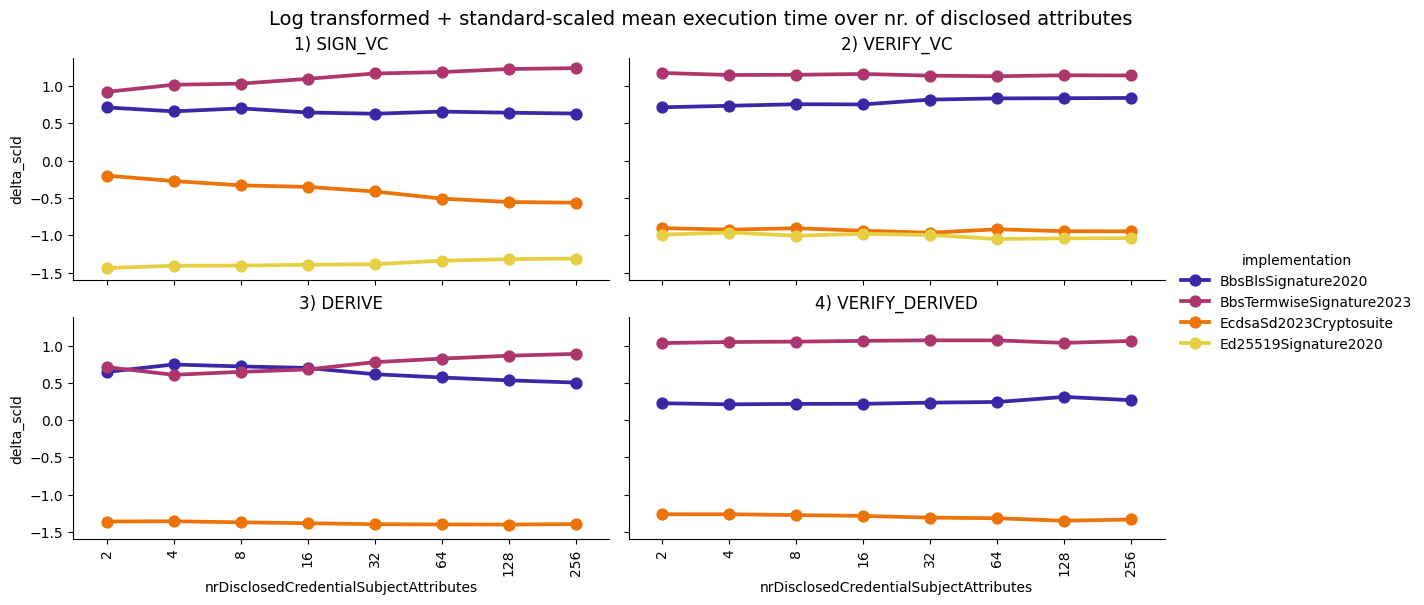

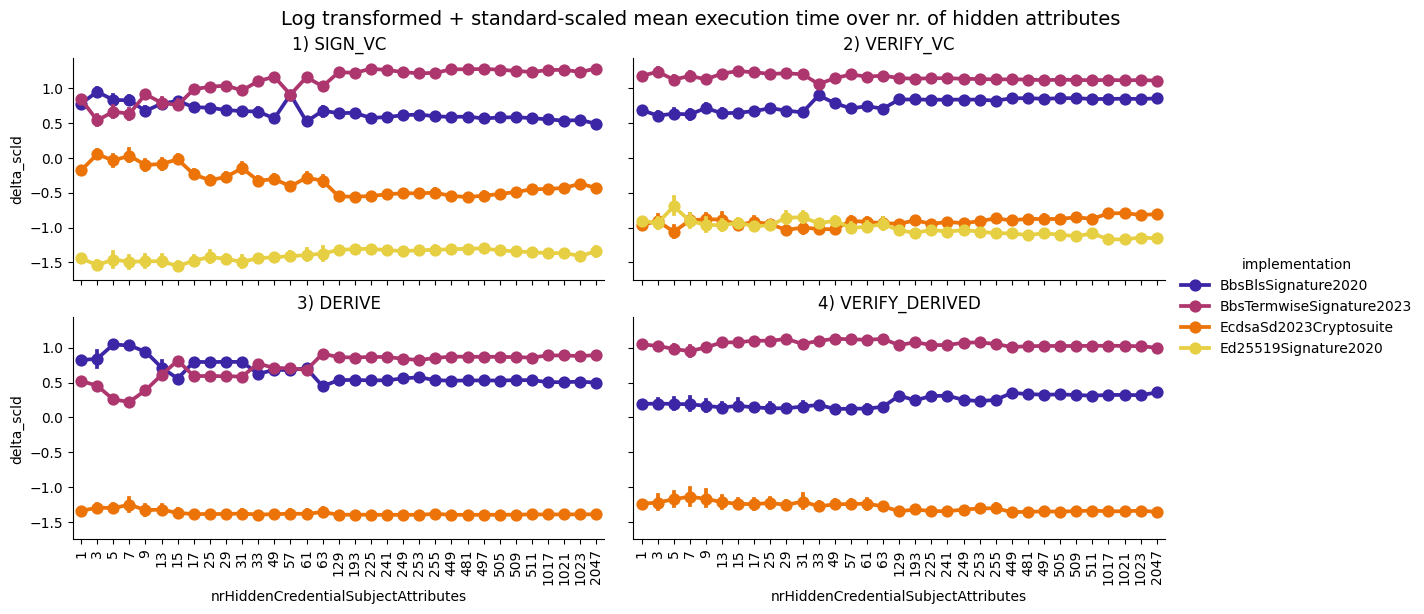

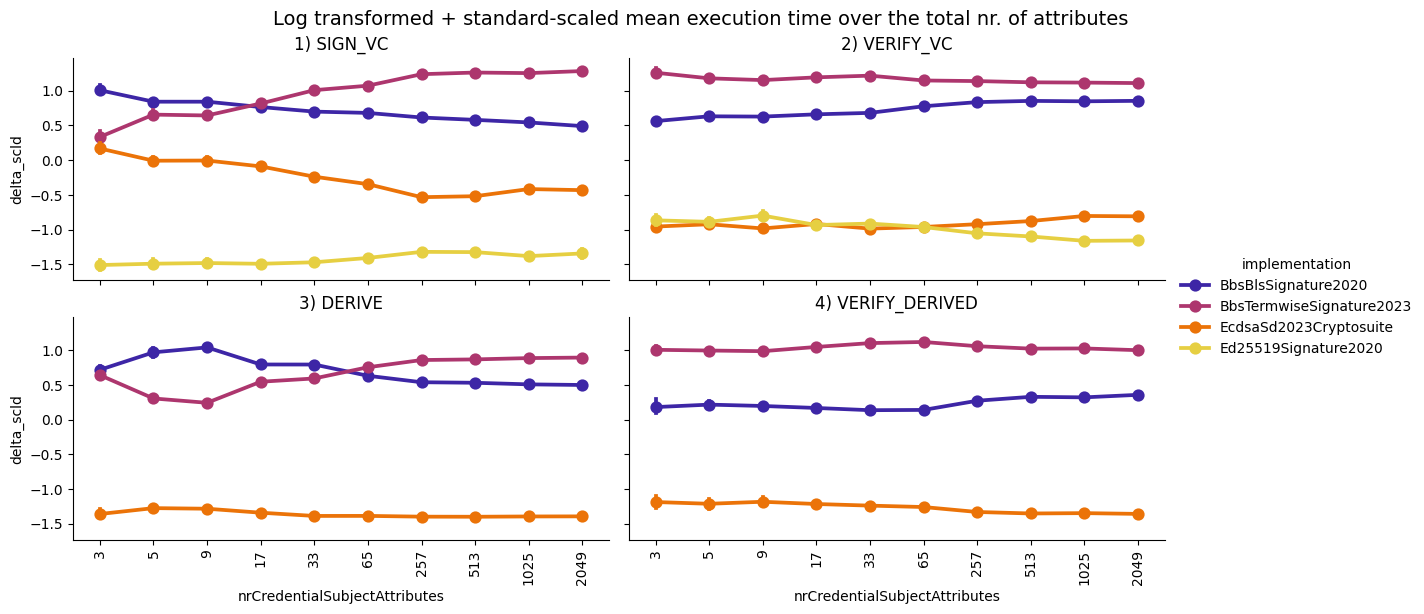

In [34]:
###########################
# 01
# vs. nr of disclosed attributes
fname_catplot_01 = 'std-scaled-mean-execution-time-vs-nrDisclosedCredentialSubjectAttributes.png'
g01 = cpc01.create_plot()
g01.savefig(fname_catplot_01)

###########################
# 02
# vs nr. hidden attributes
fname_catplot_02 = 'std-scaled-mean-execution-time-vs-nrHiddenCredentialSubjectAttributes.png'
g02 = cpc02.create_plot()
g02.savefig(fname_catplot_02)

###########################
# 03
# vs nr. total attributes
fname_catplot_03 = 'std-scaled-mean-execution-time-vs-nrCredentialSubjectAttributes.png'
g03 = cpc03.create_plot()
g03.savefig(fname_catplot_03)

In [35]:
lpc01, lpc02, lpc03 = lineplot_configurations

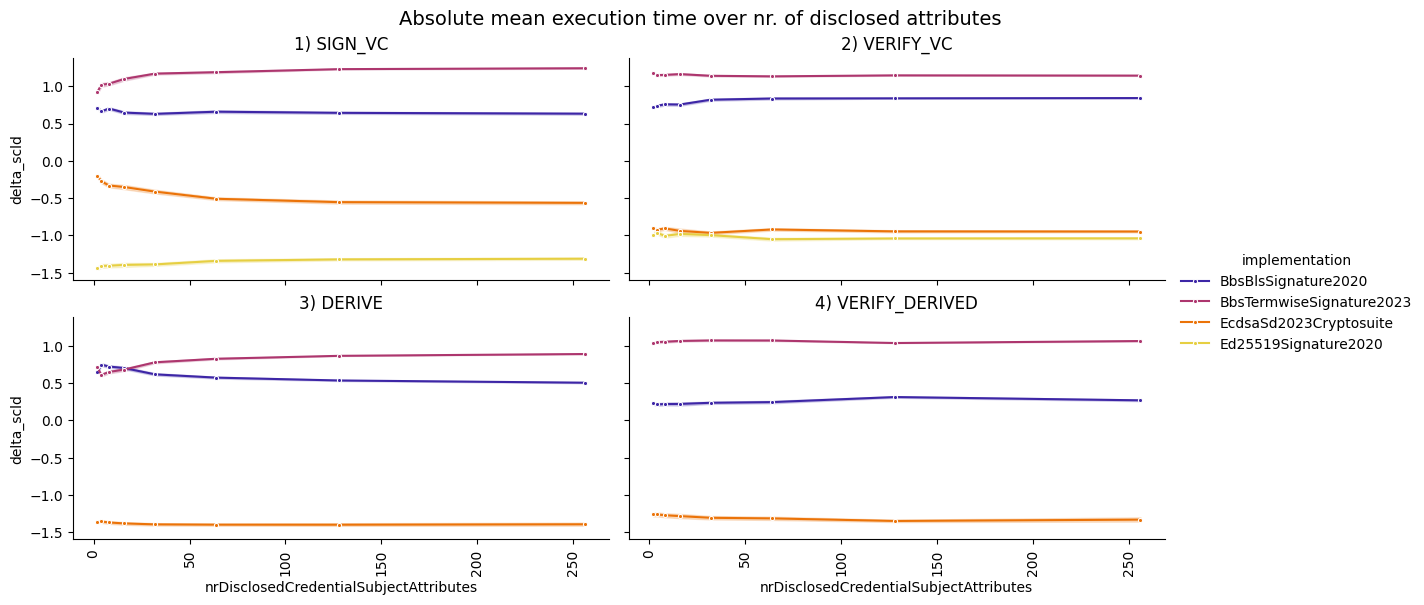

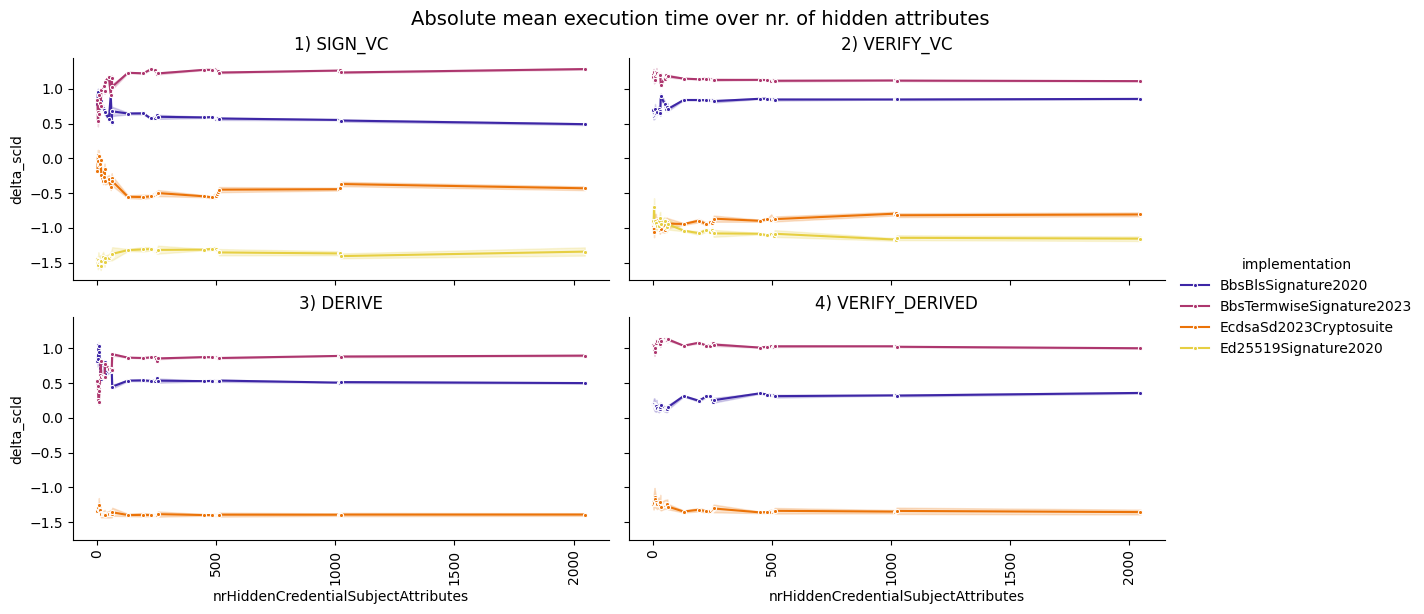

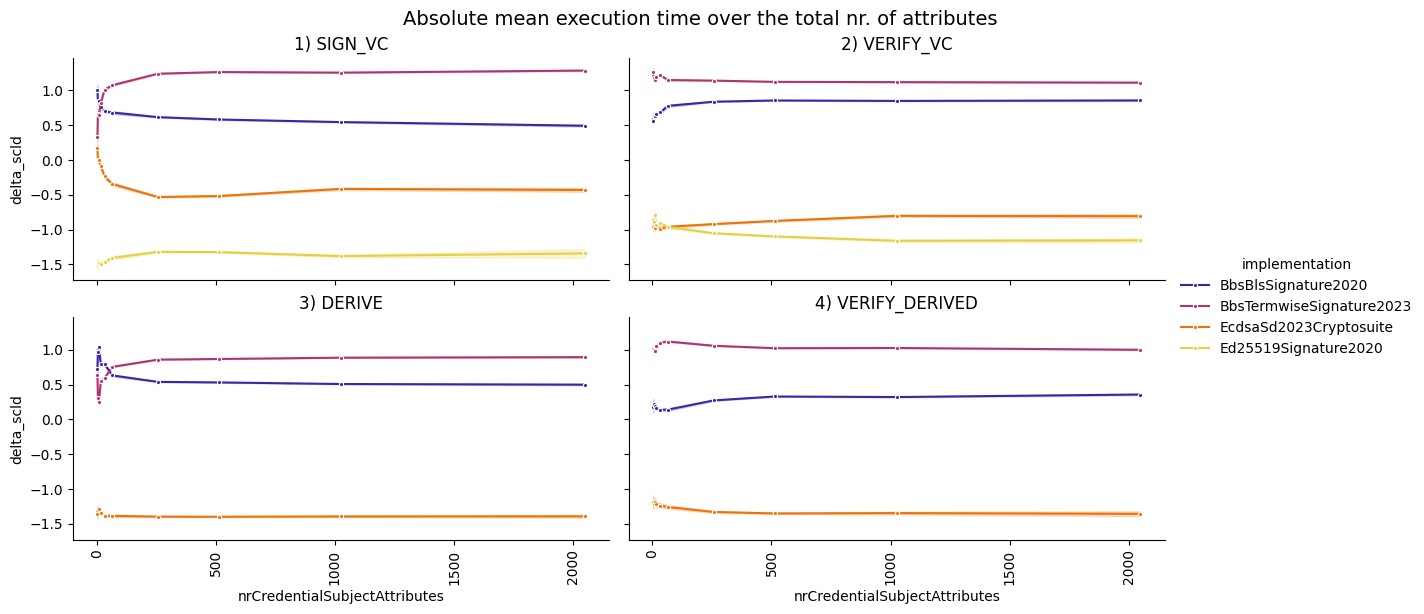

In [36]:
###########################
# 01
# vs. nr of disclosed attributes
fname_lplot_01 = 'std-scaled-mean-execution-time-vs-nrDisclosedCredentialSubjectAttributes-lineplot.png'
g01 = lpc01.create_plot()
g01.savefig(fname_lplot_01)

###########################
# 02
# vs nr. hidden attributes
fname_lplot_02 = 'std-scaled-mean-execution-time-vs-nrHiddenCredentialSubjectAttributes-lineplot.png'
g02 = lpc02.create_plot()
g02.savefig(fname_lplot_02)

###########################
# 03
# vs nr. total attributes
fname_lplot_03 = 'std-scaled-mean-execution-time-vs-nrCredentialSubjectAttributes-lineplot.png'
g03 = lpc03.create_plot()
g03.savefig(fname_lplot_03)

Create overview table (input: log-transformed & std-scaled data)

In [37]:
df_ov = pd.concat([snsdata_b01, snsdata_b02],axis=0).groupby(['implementation','step','n_sd_att'])['delta_scld'].mean()
df_ov = df_ov.unstack('implementation').loc[step_order]
df_ov.round(2).to_clipboard()
df_ov

implementation           BbsBlsSignature2020  BbsTermwiseSignature2023  \
step           n_sd_att                                                  
SIGN_VC        2                    0.714958                  0.923307   
               4                    0.662172                  1.018751   
               8                    0.701929                  1.033868   
               16                   0.647244                  1.098158   
               32                   0.630253                  1.169798   
               64                   0.659252                  1.188920   
               128                  0.644008                  1.229687   
               256                  0.632800                  1.241606   
VERIFY_VC      2                    0.716890                  1.177053   
               4                    0.736673                  1.149898   
               8                    0.757959                  1.152508   
               16                   0.755158                  1.163268   
               32                   0.819810                  1.140627   
               64                   0.836077                  1.132973   
               128                  0.838461                  1.146202   
               256                  0.841911                  1.143112   
DERIVE         2                    0.646737                  0.711923   
               4                    0.746987                  0.608374   
               8                    0.721180                  0.648049   
               16                   0.700848                  0.680780   
               32                   0.616467                  0.778039   
               64                   0.572535                  0.825667   
               128                  0.534313                  0.864664   
               256                  0.504593                  0.888925   
VERIFY_DERIVED 2                    0.227511                  1.034135   
               4                    0.212720                  1.048498   
               8                    0.218750                  1.053396   
               16                   0.219696                  1.064191   
               32                   0.235458                  1.071084   
               64                   0.244359                  1.070217   
               128                  0.312281                  1.036433   
               256                  0.268315                  1.062943   

implementation           EcdsaSd2023Cryptosuite  Ed25519Signature2020  
step           n_sd_att                                                
SIGN_VC        2                      -0.199799             -1.438466  
               4                      -0.272343             -1.408580  
               8                      -0.330048             -1.405748  
               16                     -0.350837             -1.394565  
               32                     -0.412181             -1.387871  
               64                     -0.507850             -1.340322  
               128                    -0.553256             -1.320439  
               256                    -0.562835             -1.311571  
VERIFY_VC      2                      -0.902979             -0.990965  
               4                      -0.924165             -0.962406  
               8                      -0.904935             -1.005532  
               16                     -0.938598             -0.979829  
               32                     -0.965217             -0.995220  
               64                     -0.919122             -1.049928  
               128                    -0.944928             -1.039734  
               256                    -0.946752             -1.038271  
DERIVE         2                      -1.358661                   NaN  
               4                      -1.355360                   NaN  
               8                      -1.36

## Results (absolute)

Create overview table (input: raw/absolute data)

The following aggregate overview dataframe will be computed from the absolute data:

1. `nrDisclosedCredentialSubjectAttributes` on `delta_scld`
2. `nrHiddenCredentialSubjectAttributes` on `delta_scld`
3. `nrCredentialSubjectAttributes` on `delta_scld`

In [38]:
 dfb.stack(['step','credentialSetupKey']).unstack(['implementation'])

implementation                               BbsBlsSignature2020  \
iteration step      credentialSetupKey                             
0         DERIVE    mock-vc_002-sd-002-att            235.628375   
                    mock-vc_2048-sd-002-att          4840.852417   
                    mock-vc_512-sd-008-att           1455.646375   
                    mock-vc_512-sd-016-att           1833.218500   
                    mock-vc_512-sd-032-att           1459.722708   
...                                                          ...   
99        VERIFY_VC mock-vc_256-sd-008-att            376.459125   
                    mock-vc_256-sd-016-att            392.414459   
                    mock-vc_256-sd-032-att            363.286375   
                    mock-vc_256-sd-064-att            366.211417   
                    mock-vc_032-sd-032-att             77.519417   

implementation                               BbsTermwiseSignature2023  \
iteration step      credentialSetupKey                                  
0         DERIVE    mock-vc_002-sd-002-att                 192.932166   
                    mock-vc_2048-sd-002-att              10113.831166   
                    mock-vc_512-sd-008-att                2630.541666   
                    mock-vc_512-sd-016-att                2507.226584   
                    mock-vc_512-sd-032-att                2502.143125   
...                                                               ...   
99        VERIFY_VC mock-vc_256-sd-008-att                 609.890417   
                    mock-vc_256-sd-016-att                 610.297542   
                    mock-vc_256-sd-032-att                 608.445959   
                    mock-vc_256-sd-064-att                 606.107209   
                    mock-vc_032-sd-032-att                 124.951458   

implementation                               EcdsaSd2023Cryptosuite  \
iteration step      credentialSetupKey                                
0         DERIVE    mock-vc_002-sd-002-att                46.091917   
                    mock-vc_2048-sd-002-att              275.176292   
                    mock-vc_512-sd-008-att                61.706625   
                    mock-vc_512-sd-016-att                57.440000   
                    mock-vc_512-sd-032-att                54.486791   
...                                                             ...   
99        VERIFY_VC mock-vc_256-sd-008-att                20.560334   
                    mock-vc_256-sd-016-att                18.727250   
                    mock-vc_256-sd-032-att                19.976791   
                    mock-vc_256-sd-064-att                19.080458   
                    mock-vc_032-sd-032-att                13.529791   

implementation                               Ed25519Signature2020  
iteration step      credentialSetupKey                             
0         DERIVE    mock-vc_002-sd-002-att                    NaN  
                    mock-vc_2048-sd-002-att                   NaN  
                    mock-vc_512-sd-008-att                    NaN  
                    mock-vc_512-sd-016-att                    NaN  
                    mock-vc_512-sd-032-att                    NaN  
...                                                           ...  
99        VERIFY_VC mock-vc_256-sd-008-att              24.322375  
                    mock-vc_256-sd-016-att              14.421875  
                    mock-vc_256-sd-032-att              17.680667  
                    mock-vc_256-sd-064-att              14.350917  
                    mock-vc_032-sd-032-att              15.066917  

[15600 rows x 4 columns]

In [39]:
df_abs = dfb.stack('credentialSetupKey')
df_abs = df_abs.stack().rename('mean_delta').reset_index()
# merge with meta dataframe
df_abs = df_abs.merge(get_df_meta(), on='credentialSetupKey')
abs_factor = 1e-3
df_abs['mean_delta'] = df_abs['mean_delta']*abs_factor
df_abs

⚠️ Falling back to experiments with the max nr. of iterations!


/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_57094/2409186093.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  df_meta = get_dfa().groupby(['credentialSetupKey'])['nrCredentialSubjectAttributes','nrDisclosedCredentialSubjectAttributes'].first().reset_index()


,implementation,iteration,credentialSetupKey,step,mean_delta,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,nrHiddenCredentialSubjectAttributes
0,BbsBlsSignature2020,0,mock-vc_002-sd-002-att,DERIVE,0.235628,3,2,1
1,BbsBlsSignature2020,0,mock-vc_002-sd-002-att,SIGN_VC,0.252895,3,2,1
2,BbsBlsSignature2020,0,mock-vc_002-sd-002-att,VERIFY_DERIVED,0.044471,3,2,1
3,BbsBlsSignature2020,0,mock-vc_002-sd-002-att,VERIFY_VC,0.060016,3,2,1
4,BbsBlsSignature2020,1,mock-vc_002-sd-002-att,DERIVE,0.163379,3,2,1
...,...,...,...,...,...,...,...,...
54595,Ed25519Signature2020,97,mock-vc_512-sd-064-att,VERIFY_VC,0.017651,513,64,449
54596,Ed25519Signature2020,98,mock-vc_512-sd-064-att,SIGN_VC,0.015946,513,64,449
54597,Ed25519Signature2020,98,mock-vc_512-sd-064-att,VERIFY_VC,0.018346,513,64,449
54598,Ed25519Signature2020,99,mock-vc_512-sd-064-att,SIGN_VC,0.016601,513,64,449


In [40]:
# gci: group col <i>
gci = 'nrDisclosedCredentialSubjectAttributes'
# group i
gi = df_abs.groupby(['step', 'implementation', gci])['mean_delta']
df_abs_01 = gi.mean().unstack('implementation').loc(axis=0)[step_order,:]
df_abs_01

implementation                                         BbsBlsSignature2020  \
step           nrDisclosedCredentialSubjectAttributes                        
SIGN_VC        2                                                  0.331968   
               4                                                  0.231890   
               8                                                  0.256045   
               16                                                 0.186778   
               32                                                 0.209150   
               64                                                 0.265601   
               128                                                0.263529   
               256                                                0.256647   
VERIFY_VC      2                                                  0.575559   
               4                                                  0.363412   
               8                                                  0.389963   
               16                                                 0.273698   
               32                                                 0.333510   
               64                                                 0.407586   
               128                                                0.372338   
               256                                                0.377918   
DERIVE         2                                                  1.252882   
               4                                                  0.899318   
               8                                                  0.951972   
               16                                                 0.722399   
               32                                                 0.769394   
               64                                                 0.912019   
               128                                                0.831895   
               256                                                0.764384   
VERIFY_DERIVED 2                                                  0.277144   
               4                                                  0.183832   
               8                                                  0.201276   
               16                                                 0.156661   
               32                                                 0.180350   
               64                                                 0.218701   
               128                                                0.225602   
               256                                                0.217720   

implementation                                         BbsTermwiseSignature2023  \
step           nrDisclosedCredentialSubjectAttributes                             
SIGN_VC        2                                                       0.968737   
               4                                                       0.600318   
               8                                                       0.654345   
               16                                                      0.441274   
               32                                                      0.519937   
               64                                                      0.655723   
               128                                                     0.604582   
               256                                                     0.609913   
VERIFY_VC      2                                                       0.977308   
               4                                                       0.596154   
               8                                                       0.661367   
               16                                                      0.447566   
               32                                                      0.532693   
               64                                                      0.665649   
               128 

In [41]:
# gci: group col <i>
gci = 'nrHiddenCredentialSubjectAttributes'
# group i
gi = df_abs.groupby(['step', 'implementation', gci])['mean_delta']
df_abs_02 = gi.mean().unstack('implementation').loc(axis=0)[step_order,:]
df_abs_02

implementation                                      BbsBlsSignature2020  \
step           nrHiddenCredentialSubjectAttributes                        
SIGN_VC        1                                               0.127303   
               3                                               0.088365   
               5                                               0.098615   
               7                                               0.103722   
               9                                               0.102862   
...                                                                 ...   
VERIFY_DERIVED 511                                             0.386493   
               1017                                            0.570997   
               1021                                            0.566776   
               1023                                            0.641803   
               2047                                            1.102069   

implementation                                      BbsTermwiseSignature2023  \
step           nrHiddenCredentialSubjectAttributes                             
SIGN_VC        1                                                    0.184457   
               3                                                    0.069119   
               5                                                    0.089644   
               7                                                    0.092177   
               9                                                    0.122567   
...                                                                      ...   
VERIFY_DERIVED 511                                                  1.328000   
               1017                                                 2.244867   
               1021                                                 2.286402   
               1023                                                 2.461312   
               2047                                                 4.626457   

implementation                                      EcdsaSd2023Cryptosuite  \
step           nrHiddenCredentialSubjectAttributes                           
SIGN_VC        1                                                  0.051372   
               3                                                  0.049648   
               5                                                  0.056001   
               7                                                  0.061315   
               9                                                  0.057586   
...                                                                    ...   
VERIFY_DERIVED 511                                                0.023467   
               1017                                               0.022865   
               1021                                               0.022087   
               1023                                               0.029026   
               2047                                               0.025531   

implementation                                      Ed25519Signature2020  
step           nrHiddenCredentialSubjectAttributes                        
SIGN_VC        1                                                0.019085  
               3                                                0.017608  
               5                                                0.022410  
               7                                                0.021335  
               9                                                0.020358  
...                                                                  ...  
VERIFY_DERIVED 511                                                   NaN  
               1017                                                  NaN  
               1021                                                  NaN  
               1023                                                  NaN  
               2047                                                 

In [42]:
# gci: group col <i>
gci = 'nrCredentialSubjectAttributes'
# group i
gi = df_abs.groupby(['step', 'implementation', gci])['mean_delta']
df_abs_03 = gi.mean().unstack('implementation').loc(axis=0)[step_order,:]
df_abs_03

implementation                                BbsBlsSignature2020  \
step           nrCredentialSubjectAttributes                        
SIGN_VC        3                                         0.088509   
               5                                         0.091850   
               9                                         0.099400   
               17                                        0.102944   
               33                                        0.103243   
               65                                        0.159336   
               257                                       0.264187   
               513                                       0.393488   
               1025                                      0.646402   
               2049                                      1.186546   
VERIFY_VC      3                                         0.047199   
               5                                         0.054177   
               9                                         0.063271   
               17                                        0.070008   
               33                                        0.087885   
               65                                        0.152657   
               257                                       0.390506   
               513                                       0.722012   
               1025                                      1.332526   
               2049                                      2.633695   
DERIVE         3                                         0.182249   
               5                                         0.323071   
               9                                         0.407822   
               17                                        0.334819   
               33                                        0.398347   
               65                                        0.470173   
               257                                       0.895115   
               513                                       1.509509   
               1025                                      2.629527   
               2049                                      5.098617   
VERIFY_DERIVED 3                                         0.053148   
               5                                         0.053846   
               9                                         0.061472   
               17                                        0.065835   
               33                                        0.071809   
               65                                        0.093573   
               257                                       0.213215   
               513                                       0.356453   
               1025                                      0.593192   
               2049                                      1.102069   

implementation                                BbsTermwiseSignature2023  \
step           nrCredentialSubjectAttributes                             
SIGN_VC        3                                              0.059513   
               5                                              0.083899   
               9                                              0.088104   
               17                                             0.108371   
               33                                             0.131756   
               65                                             0.224932   
               257                                            0.630046   
               513                                            1.178893   
               1025                                           2.300239   
               2049                                           4.590190   
VERIFY_VC      3                                              0.074319   
               5                                              0.078300   
               9                                              0.0

In [43]:
list(filter(lambda c: c != 'mean_delta', list(df_abs.columns)))

['implementation',
 'iteration',
 'credentialSetupKey',
 'step',
 'nrCredentialSubjectAttributes',
 'nrDisclosedCredentialSubjectAttributes',
 'nrHiddenCredentialSubjectAttributes']

In [44]:
snsdata_abs = df_abs.set_index(list(filter(lambda c: c != 'mean_delta', list(df_abs.columns)))).reset_index()
snsdata_abs

,implementation,iteration,credentialSetupKey,step,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,nrHiddenCredentialSubjectAttributes,mean_delta
0,BbsBlsSignature2020,0,mock-vc_002-sd-002-att,DERIVE,3,2,1,0.235628
1,BbsBlsSignature2020,0,mock-vc_002-sd-002-att,SIGN_VC,3,2,1,0.252895
2,BbsBlsSignature2020,0,mock-vc_002-sd-002-att,VERIFY_DERIVED,3,2,1,0.044471
3,BbsBlsSignature2020,0,mock-vc_002-sd-002-att,VERIFY_VC,3,2,1,0.060016
4,BbsBlsSignature2020,1,mock-vc_002-sd-002-att,DERIVE,3,2,1,0.163379
...,...,...,...,...,...,...,...,...
54595,Ed25519Signature2020,97,mock-vc_512-sd-064-att,VERIFY_VC,513,64,449,0.017651
54596,Ed25519Signature2020,98,mock-vc_512-sd-064-att,SIGN_VC,513,64,449,0.015946
54597,Ed25519Signature2020,98,mock-vc_512-sd-064-att,VERIFY_VC,513,64,449,0.018346
54598,Ed25519Signature2020,99,mock-vc_512-sd-064-att,SIGN_VC,513,64,449,0.016601


In [45]:
# parameters that apply to all three plots
kwargs_catplot_common_abs = dict(
    # data = snsdata_abs,
    # dev
    data  = snsdata_abs[snsdata_abs.nrCredentialSubjectAttributes>1 ],
    hue = 'implementation',
    col = 'step',
    col_order = col_order,
    col_wrap = 2,
    kind = 'point',
    height=3,
    aspect=2,
    sharey=True,
    palette=PALETTE
)


# parameters that apply to all three plots
kwargs_lineplot_common_abs = dict(
        data  = snsdata_abs[snsdata_abs.nrCredentialSubjectAttributes>1 ],
    hue = 'implementation',
    col = 'step',
    col_order = col_order,
    col_wrap = 2,
    
    height=3,
    aspect=2,
    sharey=True,
    palette="CMRmap"
)

x01 = 'nrDisclosedCredentialSubjectAttributes'
x02 = 'nrHiddenCredentialSubjectAttributes'
x03 = 'nrCredentialSubjectAttributes'

catplot_configurations_abs = [
    
    CatplotConfiguration(x01, 'mean_delta', kwargs_catplot_common_abs, "Absolute mean execution time over nr. of disclosed attributes"),
    CatplotConfiguration(x02, 'mean_delta', kwargs_catplot_common_abs, "Absolute mean execution time over nr. of hidden attributes"),
    CatplotConfiguration(x03, 'mean_delta', kwargs_catplot_common_abs, "Absolute mean execution time over the total nr. of attributes"),
]


lineplot_configurations_abs = [
    LinePlotConfiguration(x01, 'mean_delta', kwargs_lineplot_common_abs, "Absolute mean execution time over nr. of disclosed attributes"),
    LinePlotConfiguration(x02, 'mean_delta', kwargs_lineplot_common_abs, "Absolute mean execution time over nr. of hidden attributes"),
    LinePlotConfiguration(x03, 'mean_delta', kwargs_lineplot_common_abs, "Absolute mean execution time over the total nr. of attributes"),
]

In [46]:
kwargs_catplot_common_abs['data'].describe()

,iteration,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,nrHiddenCredentialSubjectAttributes,mean_delta
count,54600.000000,54600.000000,54600.000000,54600.000000,54600.000000
mean,49.500000,280.025641,22.871795,257.153846,0.403695
std,28.866334,406.103838,45.234381,410.163546,0.851538
min,0.000000,3.000000,2.000000,1.000000,0.011394
25%,24.750000,17.000000,2.000000,7.000000,0.031071
50%,49.500000,65.000000,8.000000,57.000000,0.089245
75%,74.250000,513.000000,16.000000,449.000000,0.371797
max,99.000000,2049.000000,256.000000,2047.000000,15.686231


#### Catplots (abs)

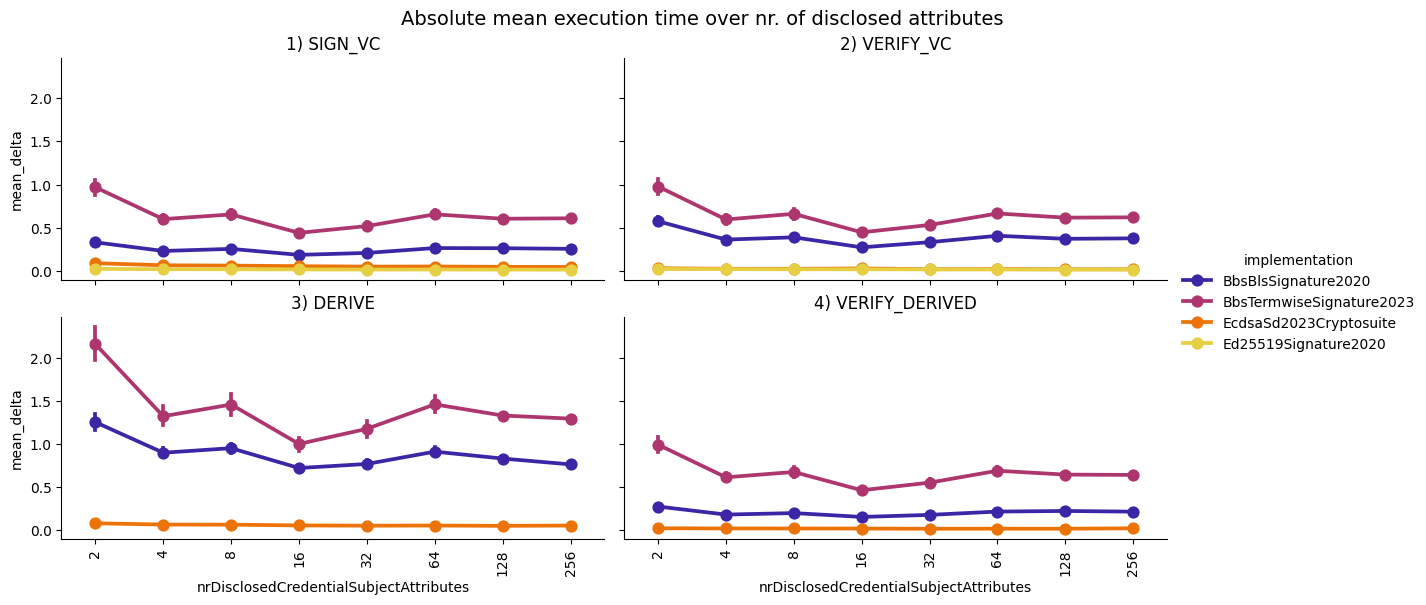

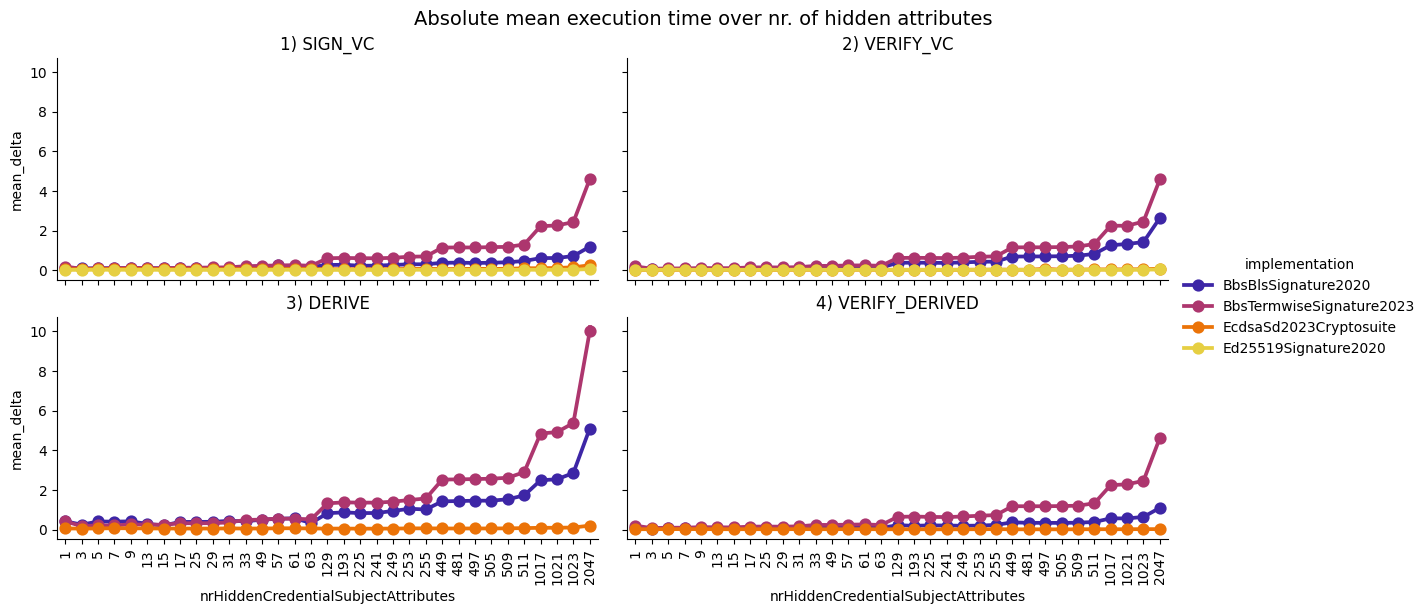

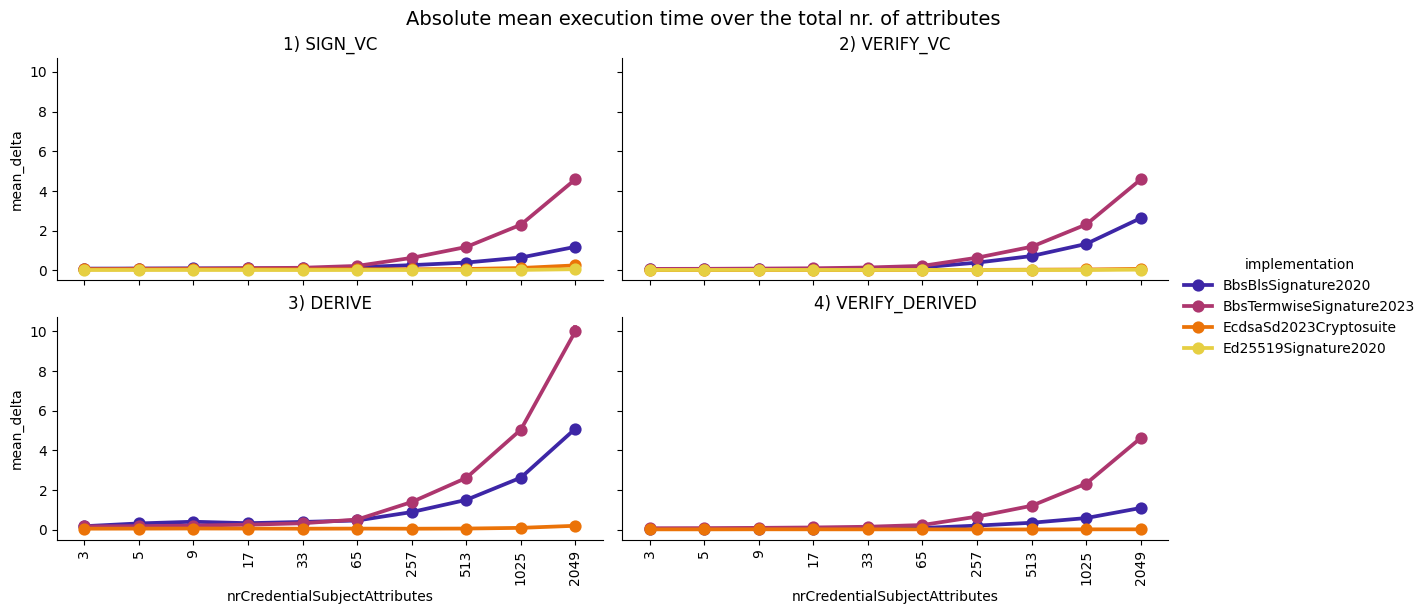

In [47]:
for i, cpc_i in enumerate(catplot_configurations_abs):
    fname_catplot_i_abs = f'abs-mean-execution-time-vs-{cpc_i.x}.png'
    g0i_abs =cpc_i.create_plot()
    g0i_abs.savefig(fname_catplot_i_abs)



#### Lineplots (abs)

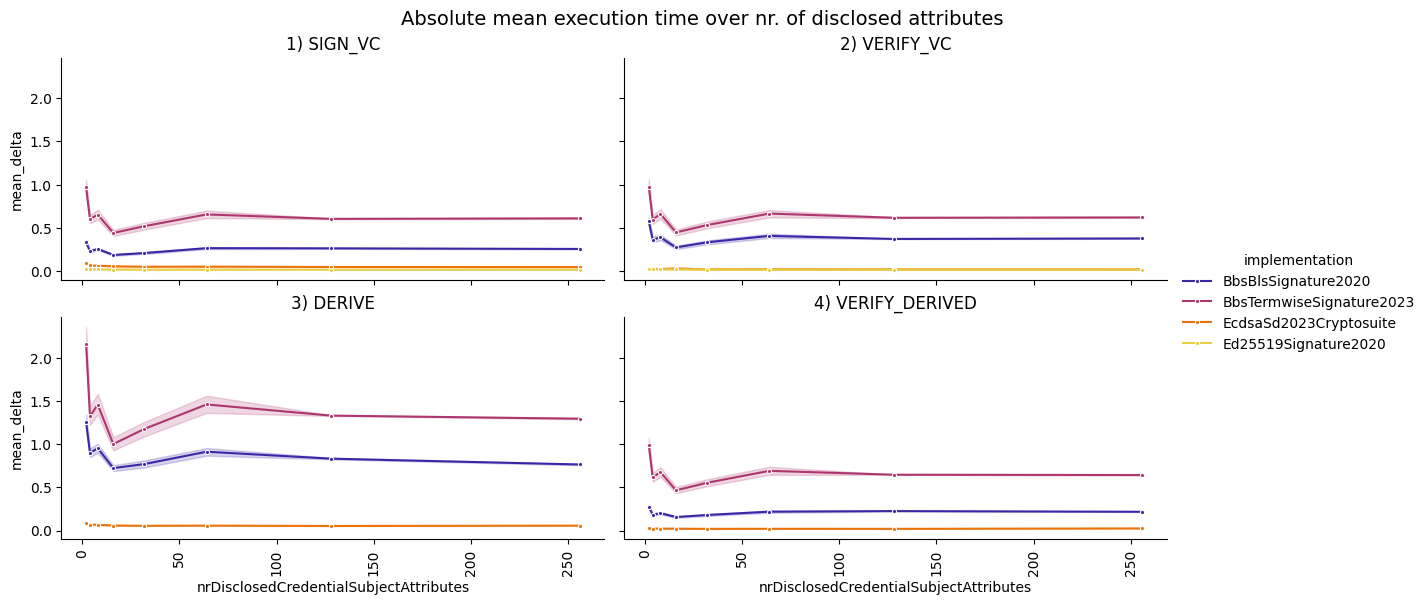

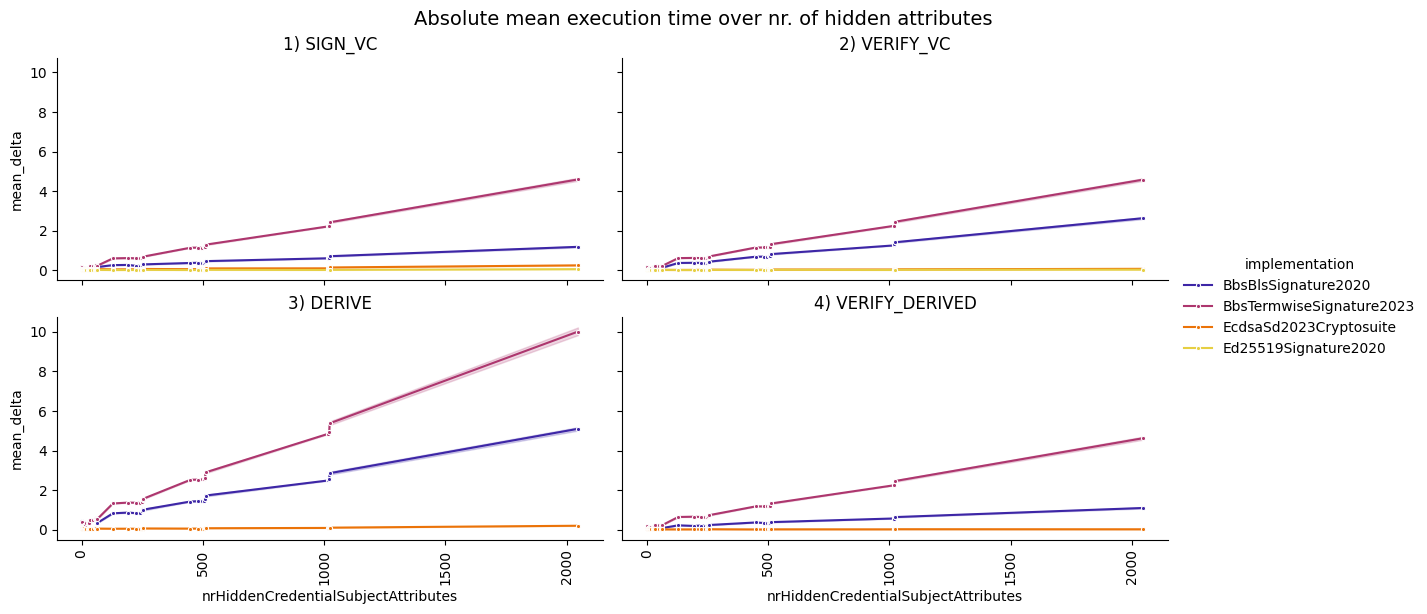

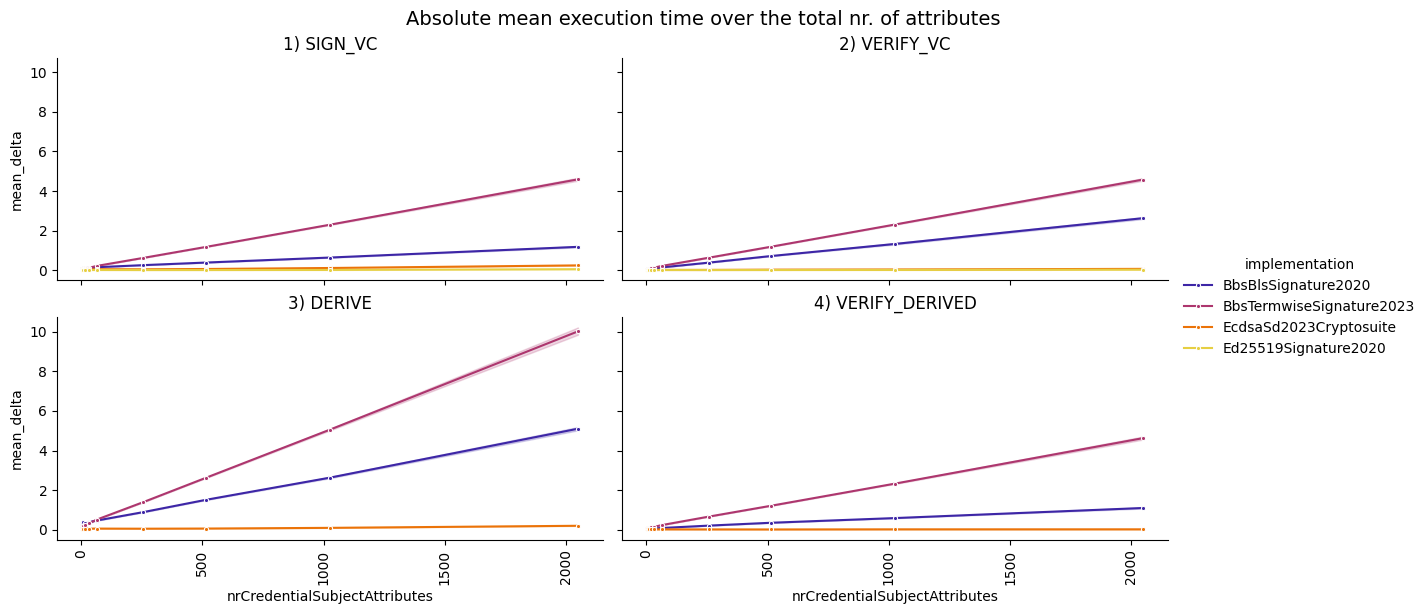

In [48]:
for i, lpc_i in enumerate(lineplot_configurations_abs):
    fname_lineplot_i_abs = f'abs-mean-execution-time-vs-{lpc_i.x}-lineplot.png'
    g0i_abs =lpc_i.create_plot()
    g0i_abs.savefig(fname_lineplot_i_abs)



### Heatmaps (abs)

In [49]:
snsdata =  dfb\
    .stack(['step','credentialSetupKey'])\
    .reset_index()\
    .rename({0:'delta_ms'},axis=1)

# abs delta mean (over iterations)
snsdata = snsdata.groupby(['implementation','step','credentialSetupKey'])['delta_ms'].mean().reset_index()
snsdata = snsdata.merge(get_df_meta(), left_on='credentialSetupKey', right_on='credentialSetupKey')
snsdata

⚠️ Falling back to experiments with the max nr. of iterations!


/var/folders/tf/j9ycytm53pzbs56ftdt8rp_w0000gn/T/ipykernel_57094/2409186093.py:2: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  df_meta = get_dfa().groupby(['credentialSetupKey'])['nrCredentialSubjectAttributes','nrDisclosedCredentialSubjectAttributes'].first().reset_index()


,implementation,step,credentialSetupKey,delta_ms,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,nrHiddenCredentialSubjectAttributes
0,BbsBlsSignature2020,DERIVE,mock-vc_002-sd-002-att,182.249224,3,2,1
1,BbsBlsSignature2020,SIGN_VC,mock-vc_002-sd-002-att,88.508661,3,2,1
2,BbsBlsSignature2020,VERIFY_DERIVED,mock-vc_002-sd-002-att,53.147805,3,2,1
3,BbsBlsSignature2020,VERIFY_VC,mock-vc_002-sd-002-att,47.199423,3,2,1
4,BbsTermwiseSignature2023,DERIVE,mock-vc_002-sd-002-att,173.238540,3,2,1
...,...,...,...,...,...,...,...
541,EcdsaSd2023Cryptosuite,SIGN_VC,mock-vc_512-sd-064-att,57.675827,513,64,449
542,EcdsaSd2023Cryptosuite,VERIFY_DERIVED,mock-vc_512-sd-064-att,18.026253,513,64,449
543,EcdsaSd2023Cryptosuite,VERIFY_VC,mock-vc_512-sd-064-att,25.162346,513,64,449
544,Ed25519Signature2020,SIGN_VC,mock-vc_512-sd-064-att,16.259399,513,64,449


In [50]:
def create_heatmap_subset(df: pd.DataFrame, _imp: str, _step: str) -> pd.DataFrame:
    subset_mask = (df.implementation == _imp)&(df.step == _step)
    sns_subset = df[subset_mask]
    sns_subset = sns_subset[['nrDisclosedCredentialSubjectAttributes','nrHiddenCredentialSubjectAttributes', 'delta_ms']]
    sns_subset.set_index(['nrDisclosedCredentialSubjectAttributes','nrHiddenCredentialSubjectAttributes',],inplace=True)
    sns_subset = sns_subset.unstack('nrHiddenCredentialSubjectAttributes')['delta_ms']
    return sns_subset

In [51]:

class HeatmapConfiguration:
    imp: str
    step: str
    df: pd.DataFrame
    subset_mask: pd.Series
    kwargs_heatmap_common = dict(vmin= 0, vmax=5)
    
    def __init__(self, imp: str, step: str, df: pd.DataFrame):
        self.df = df
        self.step = step
        self.imp = imp
        self.subset_mask = (self.df.implementation == imp)&(self.df.step == step)


    def create(self, ax):
        hm = sns.heatmap(self.subset,square=True, annot=True,ax=ax, **self.kwargs_heatmap_common)
        hm.invert_yaxis()
        
        ax.set_title(f'Implementation: {self.imp}', loc='left')
        return hm

    
    @property
    def subset(self) -> pd.DataFrame:
        return self.df[self.subset_mask]\
                    .drop(['step','implementation'],axis=1)\
                    .set_index(['nrCredentialSubjectAttributes','nrDisclosedCredentialSubjectAttributes'])['delta_ms']\
                    .sort_index()\
                    .unstack('nrDisclosedCredentialSubjectAttributes')*1e-3
        

In [52]:
heatmap_configurations = [
    HeatmapConfiguration('BbsBlsSignature2020', 'DERIVE', snsdata),
    HeatmapConfiguration('BbsTermwiseSignature2023', 'DERIVE', snsdata),
    HeatmapConfiguration('EcdsaSd2023Cryptosuite', 'DERIVE', snsdata),

    HeatmapConfiguration('BbsBlsSignature2020', 'VERIFY_DERIVED', snsdata),
    HeatmapConfiguration('BbsTermwiseSignature2023', 'VERIFY_DERIVED', snsdata),
    HeatmapConfiguration('EcdsaSd2023Cryptosuite', 'VERIFY_DERIVED', snsdata)
]

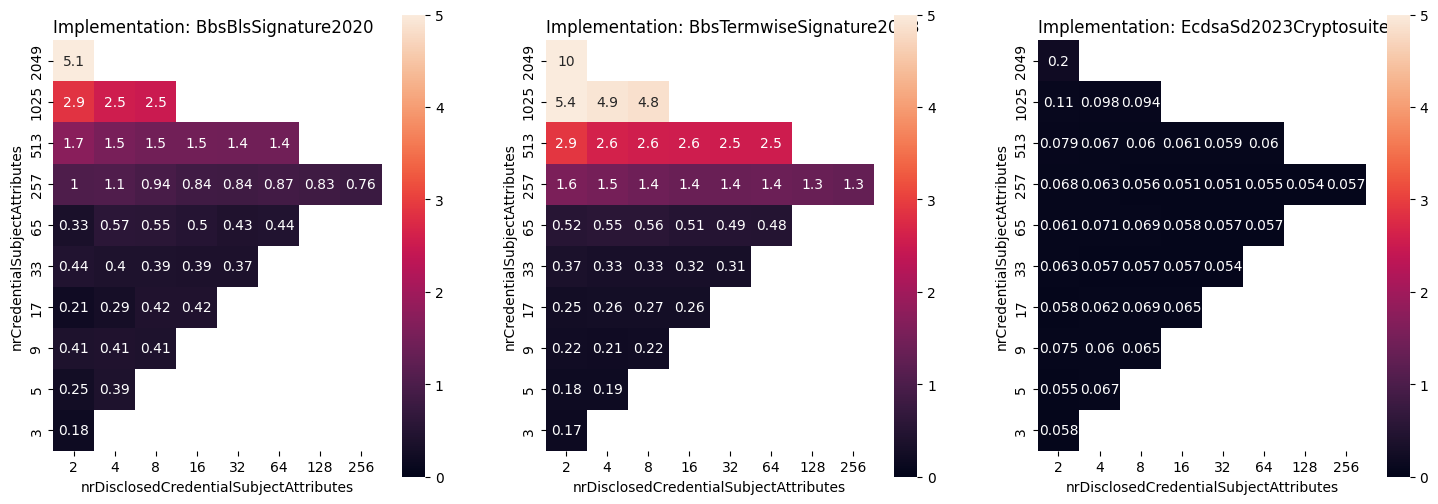

In [53]:
f, axes = plt.subplots(1,3, figsize=(18,6))

i = 0
hmci = heatmap_configurations[i]

for i in range(0, 3):
    ax = axes[i]
    hmci = heatmap_configurations[i]
    hm = hmci.create(ax)


f.savefig('heatmaps-DERIVE.png')
plt.show()

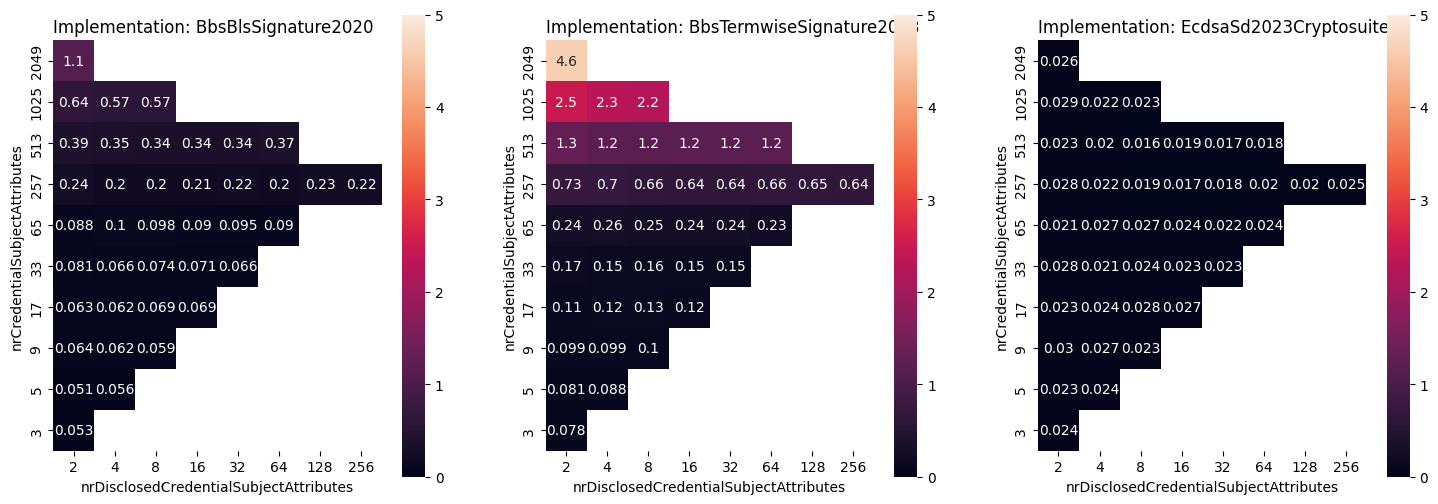

In [54]:
f, axes = plt.subplots(1,3, figsize=(18,6))

i = 0
hmci = heatmap_configurations[i]

for i in range(0, 3):
    ax = axes[i]
    hmci = heatmap_configurations[i+3]
    hm = hmci.create(ax)


f.savefig('heatmaps-VERIFY_DERIVED.png', pad_inches=2)
plt.show()

In [55]:
len(heatmap_configurations)

6

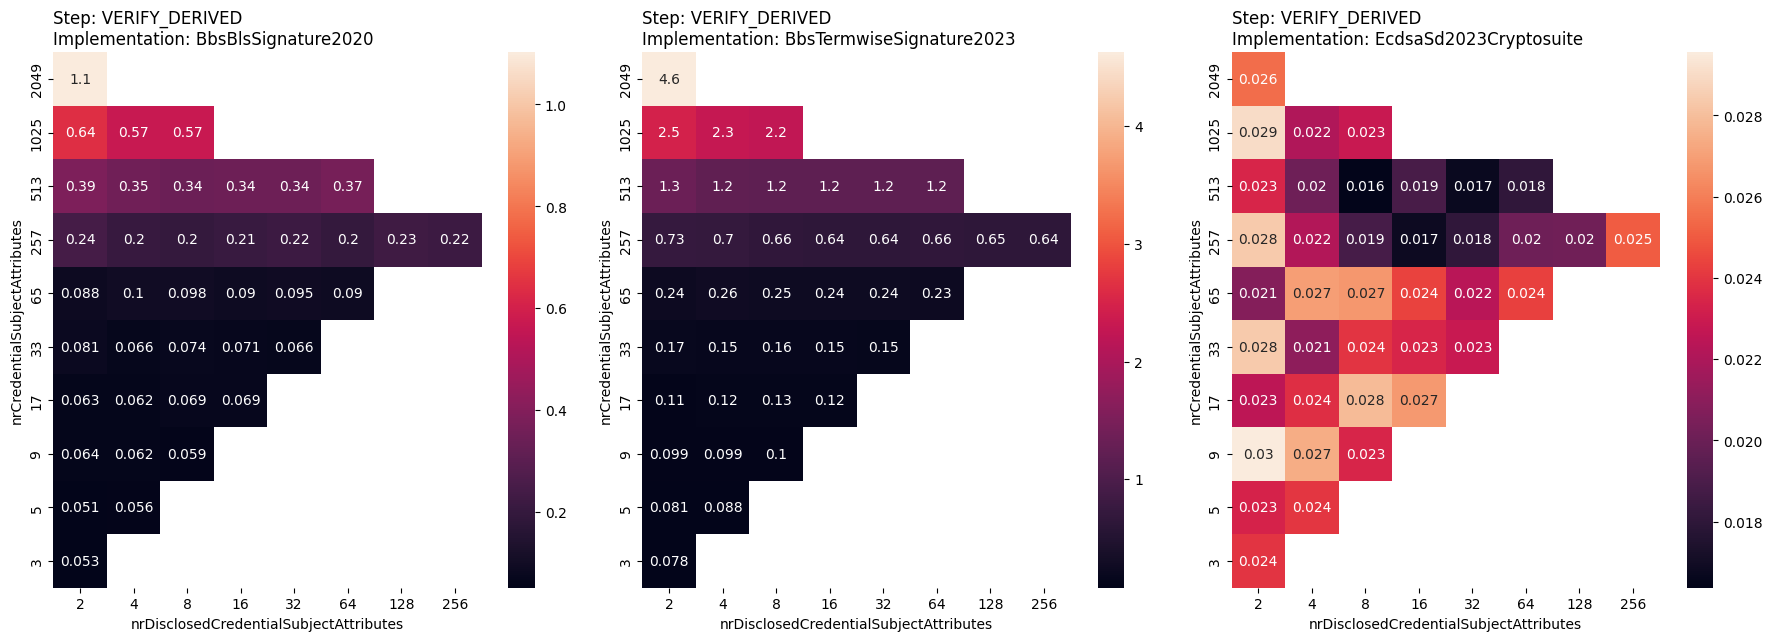

In [56]:
f, axes = plt.subplots(1,3, figsize=(18,6))

i = 0
hmci = heatmap_configurations[i+3]
ax = axes[i]

hm = sns.heatmap(hmci.subset,square=True, annot=True,ax=ax)
hm.invert_yaxis()
ax.set_title(f'Step: {hmci.step}\nImplementation: {hmci.imp}', loc='left')

i = 1
hmci = heatmap_configurations[i+3]
ax = axes[i]
hm = sns.heatmap(hmci.subset,square=True, annot=True,ax=ax)
hm.invert_yaxis()
ax.set_title(f'Step: {hmci.step}\nImplementation: {hmci.imp}', loc='left')

i = 2
hmci = heatmap_configurations[i+3]
ax = axes[i]
hm = sns.heatmap(hmci.subset,square=True, annot=True,ax=ax)
hm.invert_yaxis()
ax.set_title(f'Step: {hmci.step}\nImplementation: {hmci.imp}', loc='left')


f.tight_layout()
plt.show()

# Credential input metrics

In [57]:
df_cred_inputs =  df[['credentialSetupKey','nrCredentialSubjectAttributes','nrDisclosedCredentialSubjectAttributes']].drop_duplicates(ignore_index=True)
df_cred_inputs['nrHiddenCredentialSubjectAttributes'] = df_cred_inputs['nrCredentialSubjectAttributes'] - df_cred_inputs['nrDisclosedCredentialSubjectAttributes']
df_cred_inputs

,credentialSetupKey,nrCredentialSubjectAttributes,nrDisclosedCredentialSubjectAttributes,nrHiddenCredentialSubjectAttributes
0,mock-vc_002-sd-002-att,3,2,1
1,mock-vc_004-sd-002-att,5,2,3
2,mock-vc_004-sd-004-att,5,4,1
3,mock-vc_008-sd-002-att,9,2,7
4,mock-vc_008-sd-004-att,9,4,5
5,mock-vc_008-sd-008-att,9,8,1
6,mock-vc_064-sd-002-att,65,2,63
7,mock-vc_064-sd-004-att,65,4,61
8,mock-vc_064-sd-008-att,65,8,57
9,mock-vc_064-sd-016-att,65,16,49


# Export to Excel

In [58]:
xlw = pd.ExcelWriter(fpath_xl_output)
df_stat.to_excel(xlw, sheet_name='df_stat')
df_mean.to_excel(xlw, sheet_name='df_mean')
df_cred_inputs.to_excel(xlw, sheet_name='df_cred_inputs')
df_abs_01.to_excel(xlw, sheet_name='df_abs_01')
df_abs_02.to_excel(xlw, sheet_name='df_abs_02')
df_abs_03.to_excel(xlw, sheet_name='df_abs_03')
xlw.close()

---